# ГП4. EDA и Гипотезы

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro, chi2_contingency, levene, mannwhitneyu, ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests


In [2]:
df = pd.read_csv("e-shop clothing 2008.csv", sep=";")



---

Для удобства работы с датасетом заменим категориальные переменные их реальными названиями текстом из e-shop clothing 2008 data description.txt

---



In [3]:
countries_str = '''1-Australia\n2-Austria\n3-Belgium\n4-British Virgin Islands\n5-Cayman Islands\n6-Christmas Island\n7-Croatia\n8-Cyprus\n9-Czech Republic\n10-Denmark\n11-Estonia\n12-unidentified\n13-Faroe Islands\n14-Finland\n15-France\n16-Germany\n17-Greece\n18-Hungary\n19-Iceland\n20-India\n21-Ireland\n22-Italy\n23-Latvia\n24-Lithuania\n25-Luxembourg\n26-Mexico\n27-Netherlands\n28-Norway\n29-Poland\n30-Portugal\n31-Romania\n32-Russia\n33-San Marino\n34-Slovakia\n35-Slovenia\n36-Spain\n37-Sweden\n38-Switzerland\n39-Ukraine\n40-United Arab Emirates\n41-United Kingdom\n42-USA\n43-biz (*.biz)\n44-com (*.com)\n45-int (*.int)\n46-net (*.net)\n47-org (*.org)'''
lst = countries_str.split("\n")
countries_dict = {}
for c in lst:
  num, country = c.split("-")
  countries_dict[num] = country

df['country'] = df['country'].astype(str)
for key, item in countries_dict.items():
  df.loc[df['country'] == key, "country"] = item

In [4]:
category_str = '''1-trousers\n2-skirts\n3-blouses\n4-sale'''
lst = category_str.split("\n")
category_dict = {}
for c in lst:
  num, cat = c.split("-")
  category_dict[num] = cat

df['page 1 (main category)'] = df['page 1 (main category)'].astype(str)
for key, item in category_dict.items():
  df.loc[df['page 1 (main category)'] == key, 'page 1 (main category)'] = item

In [5]:
colour_str = '''1-beige\n2-black\n3-blue\n4-brown\n5-burgundy\n6-gray\n7-green\n8-navy blue\n9-of many colors\n10-olive\n11-pink\n12-red\n13-violet\n14-white'''
lst = colour_str.split("\n")
colour_dict = {}
for c in lst:
  num, col = c.split("-")
  colour_dict[num] = col

df['colour'] = df['colour'].astype(str)
for key, item in colour_dict.items():
  df.loc[df['colour'] == key, 'colour'] = item

In [6]:
loc_str = '''1-top left\n2-top in the middle\n3-top right\n4-bottom left\n5-bottom in the middle\n6-bottom right'''
lst = loc_str.split("\n")
loc_dict = {}
for c in lst:
  num, loc = c.split("-")
  loc_dict[num] = loc

df['location'] = df['location'].astype(str)
for key, item in loc_dict.items():
  df.loc[df['location'] == key, 'location'] = item

In [7]:
df['model photography'] = df['model photography'].astype(str)
df.loc[df['model photography'] == "1", 'model photography'] = "en face"
df.loc[df['model photography'] == "2", 'model photography'] = "profile"

df.loc[df['price 2'] == 1, 'price 2'] = True
df.loc[df['price 2'] == 2, 'price 2'] = False

/tmp/ipykernel_131350/2013052409.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['price 2'] == 1, 'price 2'] = True




---

Переименуем колонки в более удобные названия, отображающие суть признака


---



In [8]:
df = df.rename(columns={"order":"click_order", "session ID":"session_id",
                   "page 1 (main category)":"main_category",
                   "page 2 (clothing model)":"clothing_model",
                   "model photography":"model_pose",
                   "price 2":"is_expensive"})

In [9]:
df['clothing_model'].value_counts().reset_index().sort_values("clothing_model")

,clothing_model,count
9,A1,2265
8,A10,2280
2,A11,2789
10,A12,2010
19,A13,1577
...,...,...
95,P8,661
189,P80,222
194,P81,202
82,P82,725


In [10]:
model_attributes = df.groupby('clothing_model').agg({
    'location': 'nunique',
    'model_pose': 'nunique',
    'price': 'nunique',
    'is_expensive': 'nunique',
    'colour': 'nunique',
    'page': 'nunique',
    'main_category': 'nunique',
}).reset_index()

In [11]:
np.max(model_attributes, axis=0)

,0
clothing_model,P9
location,1
model_pose,1
price,1
is_expensive,1
colour,1
page,1
main_category,2




---

Признак main_category	может отличаться у одной и той же модели одежды, рассмотрим эти случаи

---



In [12]:
model_attributes[model_attributes["main_category"] == 2]

,clothing_model,location,model_pose,price,is_expensive,colour,page,main_category
9,A18,1,1,1,1,1,1,2


In [13]:
df[df["clothing_model"] == "A18"].sort_values("main_category")

,year,month,day,click_order,country,session_id,main_category,clothing_model,colour,location,model_pose,price,is_expensive,page
19001,2008,4,10,27,Poland,2766,skirts,A18,brown,bottom right,en face,38,False,1
55,2008,4,1,1,Poland,9,trousers,A18,brown,bottom right,en face,38,False,1
119140,2008,7,3,17,Poland,17503,trousers,A18,brown,bottom right,en face,38,False,1
119770,2008,7,4,11,Poland,17602,trousers,A18,brown,bottom right,en face,38,False,1
120047,2008,7,4,1,Poland,17638,trousers,A18,brown,bottom right,en face,38,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60536,2008,5,12,2,Poland,8714,trousers,A18,brown,bottom right,en face,38,False,1
60552,2008,5,12,1,Poland,8718,trousers,A18,brown,bottom right,en face,38,False,1
60606,2008,5,12,3,Poland,8724,trousers,A18,brown,bottom right,en face,38,False,1
58459,2008,5,10,1,Poland,8421,trousers,A18,brown,bottom right,en face,38,False,1


Такая модель одна и её категория один раз меняется с `trousers`	на `skirts`, вероятно, это ошибка при сборе датасета - удалим ошибочную строку

In [14]:
df = df.drop(index=19001)

Соберем "каталог" моделей

In [15]:
df_aggregated = df.groupby('clothing_model').agg({
    'main_category': 'first',
    'colour': 'first',
    'location': 'first',
    'model_pose': 'first',
    'price': 'first',
    'page': 'first',
    'is_expensive': 'first'
}).reset_index()

In [16]:
df_aggregated

,clothing_model,main_category,colour,location,model_pose,price,page,is_expensive
0,A1,trousers,navy blue,top left,en face,28,1,False
1,A10,trousers,blue,bottom left,en face,38,1,False
2,A11,trousers,blue,bottom left,en face,62,1,True
3,A12,trousers,black,bottom left,en face,38,1,False
4,A13,trousers,beige,bottom in the middle,en face,28,1,False
...,...,...,...,...,...,...,...,...
212,P8,sale,black,top right,en face,28,1,False
213,P80,sale,green,top right,en face,28,5,False
214,P81,sale,brown,top right,profile,43,5,True
215,P82,sale,gray,bottom left,profile,48,5,True


Почистим данные от случаев, когда клиент кликнул два раза подряд на один и тот же товар подряд в рамках одной сессии

In [17]:
df = df.sort_values(['session_id', 'click_order']).copy()

df['prev_model'] = df.groupby('session_id')['clothing_model'].shift()
df['prev_click_order'] = df.groupby('session_id')['click_order'].shift()

mask_drop = ((df['clothing_model'] == df['prev_model']) & (df['click_order'] == df['prev_click_order'] + 1))

df = df[~mask_drop].copy()

df['click_order'] = df.sort_values(['session_id', 'click_order']).groupby('session_id')['click_order'].transform(lambda x: range(1, len(x) + 1))

In [18]:
df = df.drop(columns=["prev_model", "prev_click_order"])

In [19]:
df["date"] = pd.to_datetime(df[["year", "month", "day"]])

In [20]:
color_palette = {
    "beige": "#F5F5DC",
    "black": "#000000",
    "blue": "#0000FF",
    "brown": "#A52A2A",
    "burgundy": "#800020",
    "gray": "#808080",
    "green": "#008000",
    "navy blue": "#000080",
    "of many colors": "#ff5054",
    "olive": "#808000",
    "pink": "#FFC0CB",
    "red": "#FF0000",
    "violet": "#8F00FF",
    "white": "#FFFFFF"
}

## EDA

### Обзор данных

In [21]:
df.dtypes

,0
year,int64
month,int64
day,int64
click_order,int64
country,object
session_id,int64
main_category,object
clothing_model,object
colour,object
location,object


In [22]:
df.isnull().sum()

,0
year,0
month,0
day,0
click_order,0
country,0
session_id,0
main_category,0
clothing_model,0
colour,0
location,0


Пропусков в данных нет

In [23]:
df.describe()

,year,month,day,click_order,session_id,price,page,date
count,157888.0,157888.000000,157888.000000,157888.000000,157888.000000,157888.000000,157888.000000,157888
mean,2008.0,5.594263,14.534277,9.237523,12103.180413,43.805881,1.709649,2008-06-01 22:40:11.248480
min,2008.0,4.000000,1.000000,1.000000,1.000000,18.000000,1.000000,2008-04-01 00:00:00
25%,2008.0,4.000000,7.000000,2.000000,5965.750000,33.000000,1.000000,2008-04-25 00:00:00
50%,2008.0,5.000000,14.000000,5.000000,12061.500000,43.000000,1.000000,2008-05-31 00:00:00
75%,2008.0,7.000000,22.000000,11.000000,18266.000000,52.000000,2.000000,2008-07-08 00:00:00
max,2008.0,8.000000,31.000000,186.000000,24026.000000,82.000000,5.000000,2008-08-13 00:00:00
std,0.0,1.327747,8.841306,12.416663,7009.624338,12.539640,0.981762,NaN


#### Структура каталога



---

По анализу выше можно заметить, что для одной и той же модели (`clothing_model`) всегда совпадают `main_category`, `colour`, `location`, `model_pose`, `price`, `is_expensive`, `page`.

Это означает, что каждая карточка товара расположена на одном и том же месте на странице и всегда имеет одну и ту же цену для каждого пользователя.

Рассмотрим конкретно каталог товара из dataframe `df_aggregated`


---



In [24]:
df_aggregated.head()

,clothing_model,main_category,colour,location,model_pose,price,page,is_expensive
0,A1,trousers,navy blue,top left,en face,28,1,False
1,A10,trousers,blue,bottom left,en face,38,1,False
2,A11,trousers,blue,bottom left,en face,62,1,True
3,A12,trousers,black,bottom left,en face,38,1,False
4,A13,trousers,beige,bottom in the middle,en face,28,1,False


In [25]:
print('Категории:', ", ".join(sorted(df_aggregated['main_category'].unique())))
print('Страницы:', end=" ")
print(*sorted(df_aggregated['page'].unique()), sep=", ")
print('Расположение:', ", ".join(sorted(df_aggregated['location'].unique())))
print('Позы модели:', ", ".join(sorted(df_aggregated['model_pose'].unique())))
print('Цвета, кол-во:', len(df_aggregated['colour'].unique()))
print('Модели, кол-во:', len(df_aggregated['clothing_model'].unique()))

Категории: blouses, sale, skirts, trousers
Страницы: 1, 2, 3, 4, 5
Расположение: bottom in the middle, bottom left, bottom right, top in the middle, top left, top right
Позы модели: en face, profile
Цвета, кол-во: 14
Модели, кол-во: 217


In [26]:
df_aggregated['price'].describe()

,price
count,217.000000
mean,41.400922
std,11.688099
min,18.000000
25%,33.000000
50%,38.000000
75%,48.000000
max,82.000000


In [27]:
df_aggregated['is_expensive'].value_counts()

,count
is_expensive,
False,111
True,106


In [28]:
df_aggregated[df_aggregated['is_expensive']]['price'].min()

38

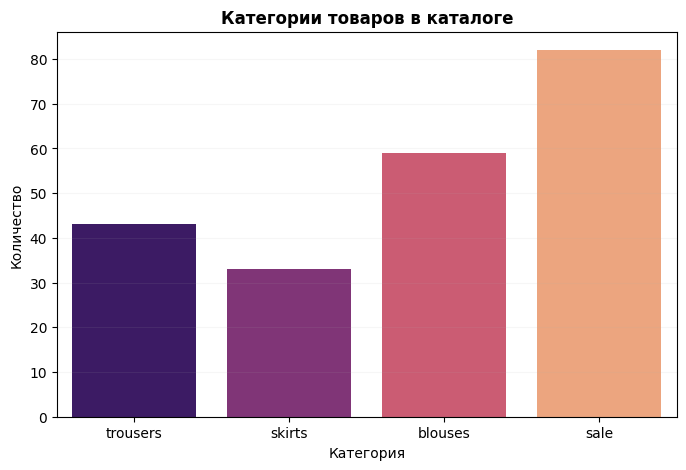

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_aggregated, x='main_category', hue='main_category', palette='magma')
plt.title('Категории товаров в каталоге', fontweight='bold')
plt.ylabel('Количество')
plt.xlabel('Категория')

plt.grid(axis='y', alpha=0.1)

plt.show()

В каталоге больше всего товаров из категории "акции", меньше всего - юбок

/tmp/ipykernel_131350/3798337691.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_aggregated, x='location', palette='magma', order = df_aggregated['location'].value_counts().index)


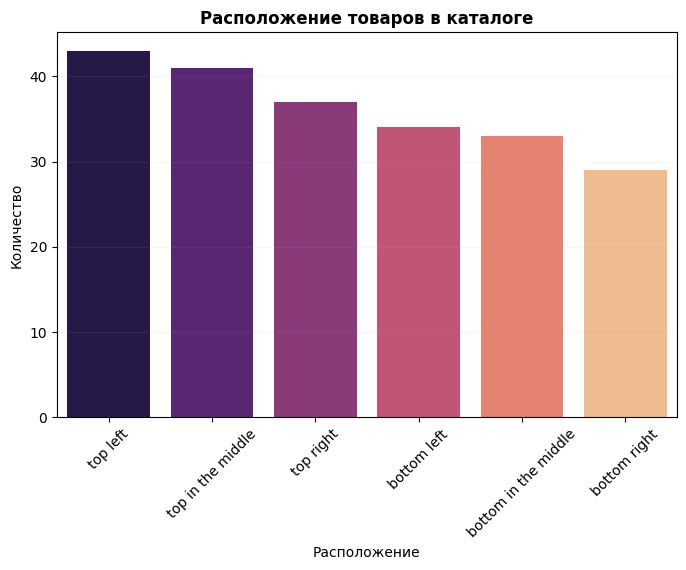

In [30]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df_aggregated, x='location', palette='magma', order = df_aggregated['location'].value_counts().index)
plt.title('Расположение товаров в каталоге', fontweight='bold')
plt.ylabel('Количество')
plt.xlabel('Расположение')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.1)

plt.show()



---

Расположение товаров по странице статично и неравномерно. Снизу страницы располагают меньше товаров

---



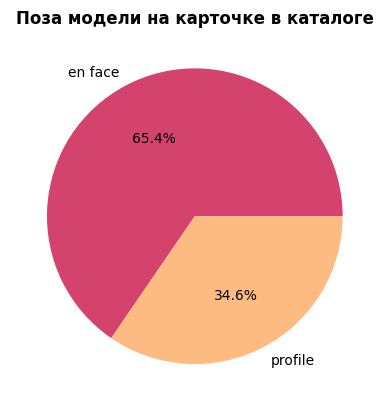

In [31]:
vc = df_aggregated['model_pose'].value_counts().reset_index()
plt.pie(x=vc['count'], labels=vc['model_pose'], autopct="%1.1f%%", colors=sns.color_palette("magma")[3:6:2])
plt.title("Поза модели на карточке в каталоге", fontweight="bold")
plt.show()

Большая часть моделей на карточках товара расположены в анфас

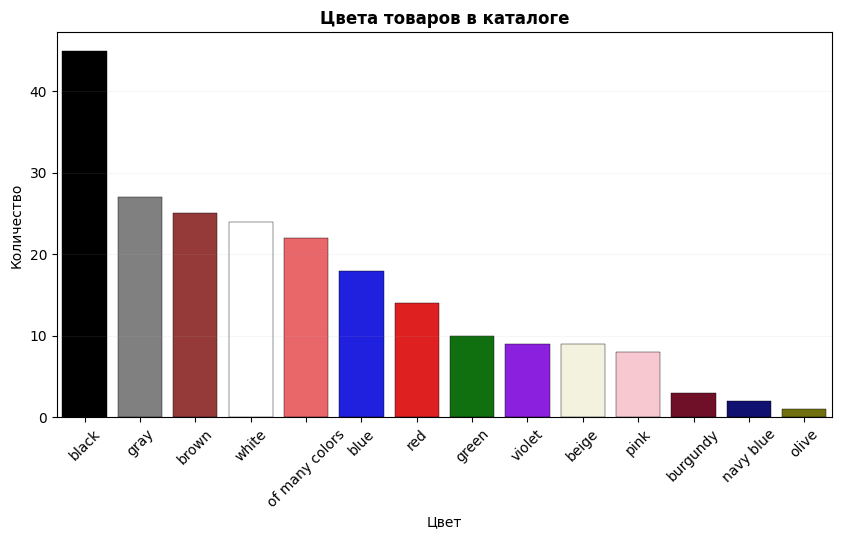

In [32]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df_aggregated, x='colour', hue="colour", palette=color_palette, edgecolor="black", linewidth=0.3,
              order = df_aggregated['colour'].value_counts().index)
plt.title('Цвета товаров в каталоге', fontweight='bold')
plt.ylabel('Количество')
plt.xlabel('Цвет')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.1)


plt.show()

Наиболее частые цвета в каталоге - черный, серый, коричневый. Наименее распространенные - темно синий и оливковый

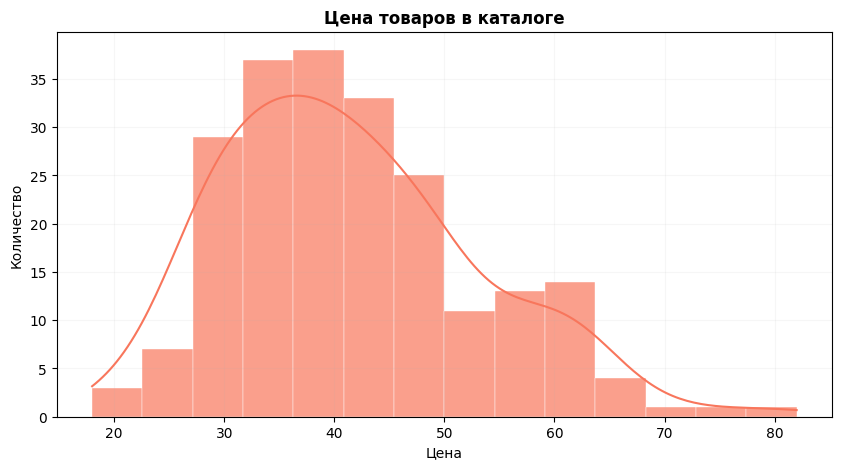

In [33]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df_aggregated, x='price', bins=14, alpha=0.7, edgecolor="white", linewidth=0.3, color=sns.color_palette("magma")[4], kde=True)
plt.title('Цена товаров в каталоге', fontweight='bold')
plt.ylabel('Количество')
plt.xlabel('Цена')
plt.grid(alpha=0.1)

plt.show()

$H_0$ - цены в каталоге распределены нормально <br>
$Н_1$ - цены в каталоге **не** распределены нормально

Уровень значимости = 0.05

In [34]:

shapiro(df_aggregated["price"])

ShapiroResult(statistic=np.float64(0.9551489443121424), pvalue=np.float64(2.6090254483845304e-06))

p-value < 0.025 -> отвергаем нулевую гипотезу -> цены в каталоге не распределены нормално

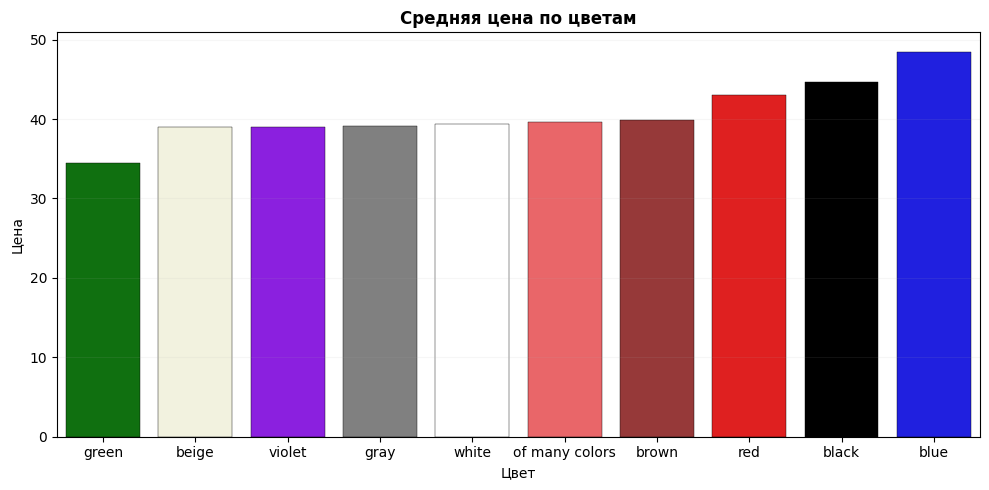

In [35]:
top_colours = df_aggregated['colour'].value_counts().head(10).index
color_price = df_aggregated[df_aggregated['colour'].isin(top_colours)].groupby('colour')['price'].mean().sort_values().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=color_price, x='colour', y='price', hue='colour',
    palette=color_palette, edgecolor="black", linewidth=0.3)

plt.title('Средняя цена по цветам', fontweight='bold')
plt.ylabel('Цена')
plt.xlabel('Цвет')
plt.grid(axis='y', alpha=0.1)
plt.tight_layout()
plt.show()

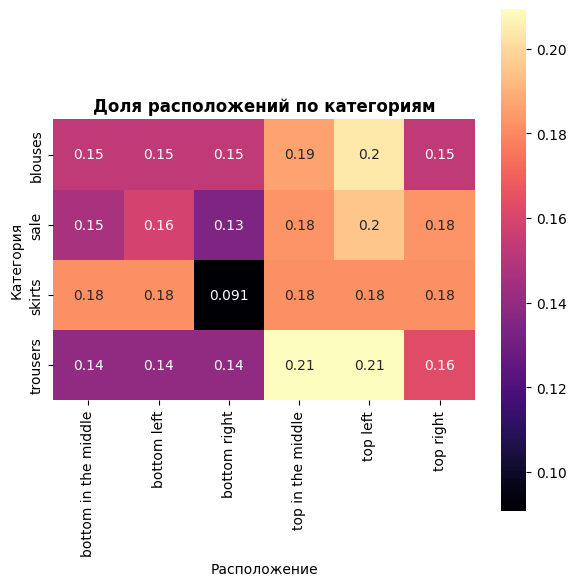

In [36]:
ct = df_aggregated.groupby('main_category')['location'].value_counts(normalize=True).unstack()

plt.figure(figsize=(6, 6))
sns.heatmap(ct, annot=True, cmap='magma', square=True)
plt.title('Доля расположений по категориям', fontweight="bold")
plt.xlabel('Расположение')
plt.ylabel('Категория')

plt.tight_layout()
plt.show()

$H_0$ - расположение товара на странице **не** зависит от его категории <br>
$Н_1$ - расположение товара на странице зависит от его категории

Уровень значимости = 0.05

In [37]:
pd.crosstab(df_aggregated['main_category'], df_aggregated['location'])

location,bottom in the middle,bottom left,bottom right,top in the middle,top left,top right
main_category,,,,,,
blouses,9,9,9,11,12,9
sale,12,13,11,15,16,15
skirts,6,6,3,6,6,6
trousers,6,6,6,9,9,7


In [38]:

contingency = pd.crosstab(df_aggregated['main_category'], df_aggregated['location'])
chi2, p, _, _ = chi2_contingency(contingency)
print(p)

0.99999520282931


p-value > 0.05 -> **не** отвергаем нулевую гипотезу -> расположение товара на странице не зависит от его категории

#### Сессии клиентов



---

Рассмотрим сессии клиентов агреггировано

---



In [39]:
df_sessions = df.groupby("session_id").agg({'click_order': 'count',
                             'country': 'first',
                             'year': 'first',
                             'month': 'first',
                             'day': 'first'}).reset_index()
df_sessions

,session_id,click_order,country,year,month,day
0,1,9,Poland,2008,4,1
1,2,9,Poland,2008,4,1
2,3,6,Ireland,2008,4,1
3,4,4,Ireland,2008,4,1
4,5,1,Czech Republic,2008,4,1
...,...,...,...,...,...,...
24021,24022,3,Poland,2008,8,13
24022,24023,7,Poland,2008,8,13
24023,24024,1,Poland,2008,8,13
24024,24025,1,Czech Republic,2008,8,13


In [40]:
print("Кол-во сессий:", len(df_sessions))

Кол-во сессий: 24026


In [41]:
df_sessions["click_order"].describe()

,click_order
count,24026.000000
mean,6.571547
std,8.464977
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,186.000000


In [42]:
all_countries = df_sessions["country"].value_counts().reset_index()

In [43]:
to_remove = ["net (*.net)", "com (*.com)", "unidentified", "biz (*.biz)", "org (*.org)"]
all_countries = all_countries[~all_countries["country"].isin(to_remove)]
top_countries = all_countries[:3].copy()
top_countries.loc["4", 'country'] = 'other'
top_countries.loc["4", 'count'] = all_countries[3:]['count'].sum()

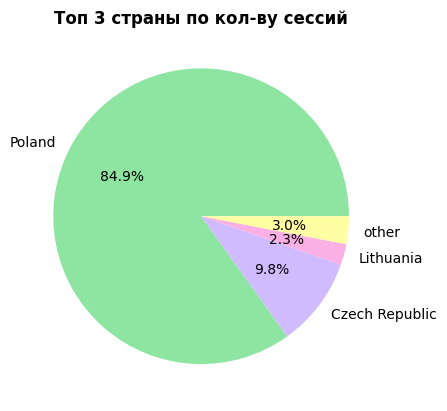

In [44]:
plt.pie(x=top_countries['count'], labels=top_countries['country'], autopct="%1.1f%%", colors=sns.color_palette("pastel")[2:10:2])
plt.title("Топ 3 страны по кол-ву сессий", fontweight="bold")
plt.show()

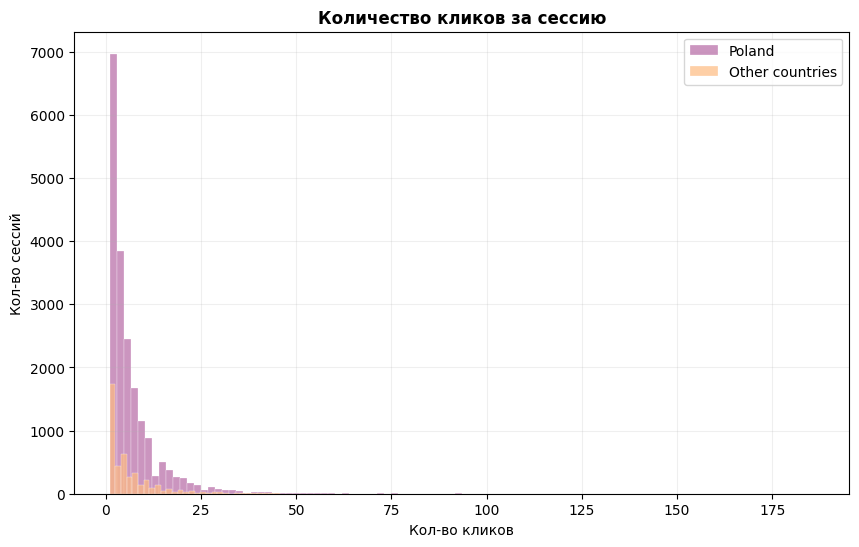

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_sessions[df_sessions['country'] == "Poland"], x="click_order", bins=100,
    alpha=0.5, edgecolor="white", linewidth=0.2, label="Poland", color=sns.color_palette("magma")[2])

sns.histplot(data=df_sessions[df_sessions['country'] != "Poland"], x="click_order", bins=100,
    alpha=0.7, edgecolor="white", linewidth=0.2, label="Other countries", color=sns.color_palette("magma")[5])

plt.title("Количество кликов за сессию", fontweight="bold")
plt.xlabel("Кол-во кликов")
plt.ylabel("Кол-во сессий")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

Видим, что почти 85% пользователей заходили на сайт из Польши. Поэтому логичнее будет рассматривать пользователей как две категории "из Польши" и "не из Польши"

In [46]:
df['region'] = df['country'].map({'Poland': 'Poland'}).fillna('Other')

In [47]:
one_click = len(df_sessions[df_sessions["click_order"] == 1]) / len(df_sessions)
print(f"{round(one_click*100, 2)}% сессий состоят из одного клика")

22.71% сессий состоят из одного клика


#### Временной промежуток



In [48]:
print(*df['year'].unique())

2008


In [49]:
print(*df['month'].unique(), sep=", ")

4, 5, 6, 7, 8


In [50]:
for month in df['month'].unique():
    days = df[df['month'] == month]['day'].unique()
    print(f'Месяц {month}, {len(days)} дней')

Месяц 4, 30 дней
Месяц 5, 31 дней
Месяц 6, 30 дней
Месяц 7, 31 дней
Месяц 8, 13 дней




---

Данные покрывают временной промежуток с апреля по август 2008 года, при этом информация про авгус приведена не полностью (только за первые 13 дней)

---



### Анализ просмотров

#### Категории

In [51]:
category_palette = {
    "trousers": sns.color_palette("magma")[0],
    "skirts": sns.color_palette("magma")[2],
    "blouses": sns.color_palette("magma")[3],
    "sale": sns.color_palette("magma")[4]
}

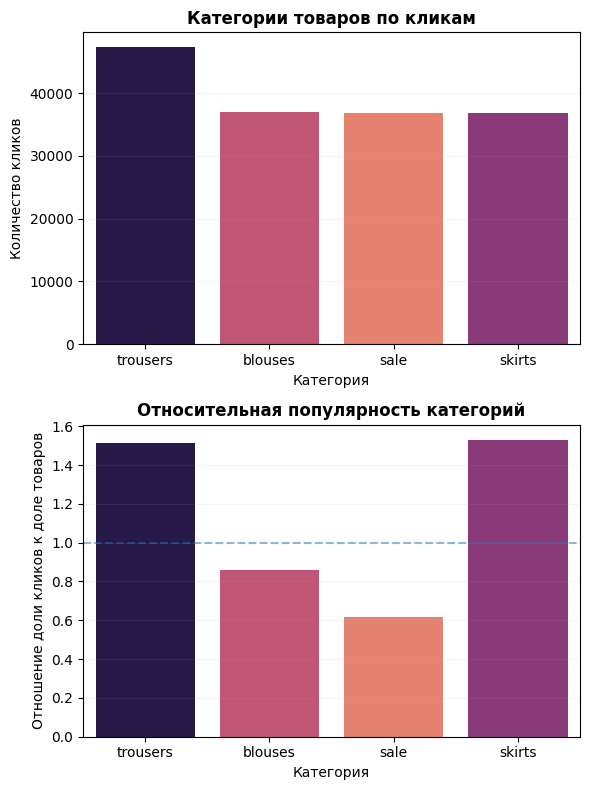

In [52]:
plt.figure(figsize=(6, 8))

plt.subplot(2, 1, 1)
sns.countplot(data=df, x='main_category', hue='main_category', palette=category_palette, order=df["main_category"].value_counts().index)
plt.title('Категории товаров по кликам', fontweight='bold')
plt.ylabel('Количество кликов')
plt.xlabel('Категория')
plt.grid(axis='y', alpha=0.1)

clicks_share = df['main_category'].value_counts(normalize=True).reset_index()
catalog_share = df_aggregated['main_category'].value_counts(normalize=True).reset_index()
shares = pd.merge(clicks_share, catalog_share, on="main_category")
shares['relative_interest'] = shares['proportion_x'] / shares['proportion_y']

plt.subplot(2, 1, 2)
sns.barplot(data=shares, x='main_category', y='relative_interest', hue='main_category', palette=category_palette)
plt.axhline(1, linestyle='--', alpha=0.5)
plt.title('Относительная популярность категорий', fontweight='bold')
plt.ylabel('Отношение доли кликов к доле товаров')
plt.xlabel('Категория')
plt.grid(axis='y', alpha=0.1)

plt.tight_layout()
plt.show()


$H_0$: Доля кликов на товары категории `trousers` **соответствует** доле товаров категории `trousers` в каталоге. Пользователи **не** проявляют повышенного или пониженного интереса к данной категории.

$H_1$: Доля кликов на товары категории `trousers` **отличается** от доли товаров категории `trousers` в каталоге. Пользователи проявляют повышенный или пониженный интерес к данной категории.



---



$H_0$: Доля кликов на товары категории `skirts` **соответствует** доле товаров категории `skirts` в каталоге. Пользователи **не** проявляют повышенного или пониженного интереса к данной категории.

$H_1$: Доля кликов на товары категории `skirts` **отличается** от доли товаров категории `skirts` в каталоге. Пользователи проявляют повышенный или пониженный интерес к данной категории.



---



$H_0$: Доля кликов на товары категории `blouses` **соответствует** доле товаров категории `blouses` в каталоге. Пользователи **не** проявляют повышенного или пониженного интереса к данной категории.

$H_1$: Доля кликов на товары категории `blouses` **отличается** от доли товаров категории `blouses` в каталоге. Пользователи проявляют повышенный или пониженный интерес к данной категории.

---

$H_0$: Доля кликов на товары категории `sale` **соответствует** доле товаров категории `sale` в каталоге. Пользователи **не** проявляют повышенного или пониженного интереса к данной категории.

$H_1$: Доля кликов на товары категории `sale` **отличается** от доли товаров категории `sale` в каталоге. Пользователи проявляют повышенный или пониженный интерес к данной категории.

---

$H_0$: Доля кликов на товары категорий **всегда соответствуют** доле товаров категории в каталоге. Пользователи **не** проявляют повышенного или пониженного интереса к категориям товаров.

$H_1$: Доля кликов на товары категорий **не всегда соответствуют** от доли товаров категории в каталоге. Пользователи проявляют повышенный или пониженный интерес к категориям товаров.

Уровень значимости = 0.05

In [53]:
results = []

ph = df.sample(2000)

for category in ph['main_category'].unique():

    z_statistic, p_value = proportions_ztest([(ph['main_category'] == category).sum(), (df_aggregated['main_category'] == category).sum()],
                                        [len(ph), len(df_aggregated)])

    results.append({
        'category': category,
        'relative_interest': float(shares[shares["main_category"] == category]["relative_interest"].iloc[0]),
        'p_value': p_value,
        'significant': p_value < 0.05,
    })

results_df = pd.DataFrame(results)
bonferroni = multipletests(results_df['p_value'], alpha=0.05, method='bonferroni')
results_df["bonferroni_pv"] = bonferroni[1]
results_df["bonferroni_significant"] = bonferroni[0]
results_df["H0"] = results_df["bonferroni_significant"].apply(lambda x: "Отвергаем" if x else "Не отвергаем")
results_df

,category,relative_interest,p_value,significant,bonferroni_pv,bonferroni_significant,H0
0,trousers,1.511991,0.002461,True,0.009844,True,Отвергаем
1,blouses,0.860812,0.219398,False,0.877592,False,Не отвергаем
2,skirts,1.530739,0.035391,True,0.141563,False,Не отвергаем
3,sale,0.618074,0.000127,True,0.000507,True,Отвергаем


Выводы:

К категориям `trousers` и `skirts` статзначимо больший интерес, а к `sale` - cтатзначимо меньший. К `blouses` интерес меньше, но не статзначимо. То есть, бизнесу стоит фокусироваться на `trousers` и `skirts`, а так же пересмотреть алгоритм формирования `sale` - сейчас он не интересует людей

Так как хотя бы в одном случае после поправки Бонферони изменения статзначимы, можно сказать, что общую $Н_0$ мы отвергаем.

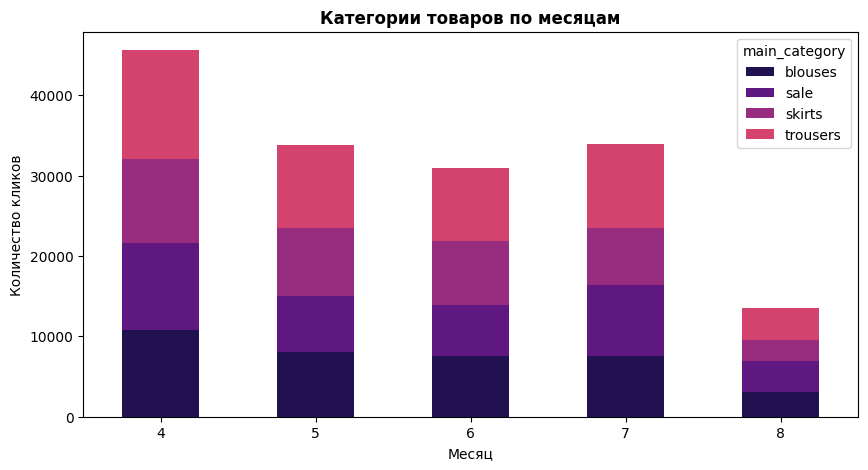

In [54]:
pivot = df.groupby(['month', 'main_category']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, figsize=(10, 5), color=sns.color_palette("magma")[0:4])
plt.title('Категории товаров по месяцам', fontweight="bold")
plt.xlabel('Месяц')
plt.ylabel('Количество кликов')
plt.xticks(rotation=0)
plt.show()

In [55]:
pivot

main_category,blouses,sale,skirts,trousers
month,,,,
4,10776,10858,10482,13506
5,7991,6970,8554,10306
6,7494,6464,7914,9079
7,7610,8764,7133,10477
8,3082,3820,2671,3937


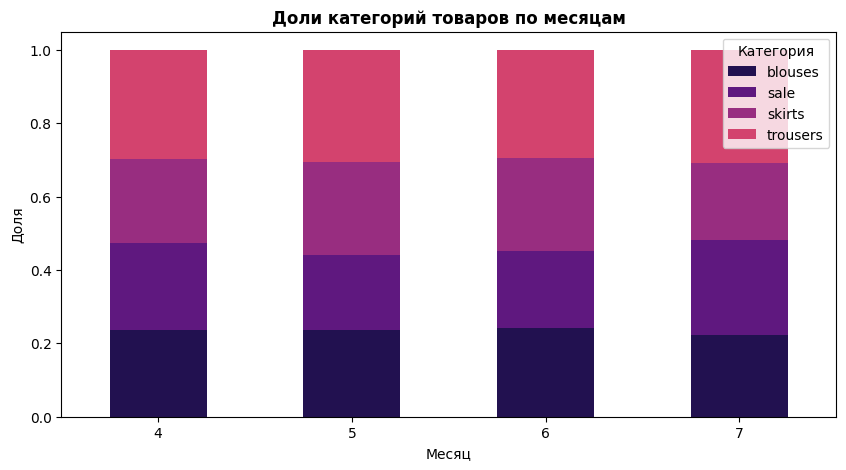

In [56]:
pivot_4_7 = pivot.loc[4:7]

pivot_percent = pivot_4_7.apply(lambda row: row / row.sum(), axis=1)

pivot_percent.plot(kind='bar', stacked=True, figsize=(10, 5), color=sns.color_palette("magma")[0:4])

plt.title('Доли категорий товаров по месяцам', fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Доля')
plt.xticks(rotation=0)
plt.legend(title='Категория')
plt.show()

$H_0$: Доля товаров категории `blouses` **не** изменяется между двумя подряд идущими месяцами. <br>
$H_1$: Доля товаров категории `blouses` изменяется хотя бы раз между двумя подряд идущими месяцами.



---



$H_0$: Доля товаров категории `sale` **не** изменяется между двумя подряд идущими месяцами. <br>
$H_1$: Доля товаров категории `sale` изменяется хотя бы раз между двумя подряд идущими месяцами.



---



$H_0$: Доля товаров категории `skirts` **не** изменяется между двумя подряд идущими месяцами. <br>
$H_1$: Доля товаров категории `skirts` изменяется хотя бы раз между двумя подряд идущими месяцами.



---



$H_0$: Доля товаров категории `trousers` **не** изменяется между двумя подряд идущими месяцами. <br>
$H_1$: Доля товаров категории `trousers` изменяется хотя бы раз между двумя подряд идущими месяцами.

---

Уровень значимости = 0.05

В данном случае поправка на множественное тестирование нужна, потому что проверяется не один статистический тест, а сразу несколько сравнений между месяцами.

В рамках каждой категории выполняются три Z-теста. Если использовать обычный уровень значимости 0.05 для каждого теста отдельно, то при множественных проверках возрастает вероятность случайно получить статистически значимый результат, даже если реальных различий нет.

In [57]:


results = []
months = [(4, 5), (5, 6), (6, 7)]

for category in pivot.columns:
    ans = []
    for m1, m2 in months:

        count_1 = pivot.loc[m1, category]
        count_2 = pivot.loc[m2, category]
        total_1 = pivot.loc[m1].sum()
        total_2 = pivot.loc[m2].sum()

        z_stat, p_value = proportions_ztest(count=[count_1, count_2], nobs=[total_1, total_2])

        ans.append({
            'category': category,
            'month_1': m1,
            'month_2': m2,
            'count_1': count_1,
            'count_2': count_2,
            'total_1': total_1,
            'total_2': total_2,
            'share_1': count_1 / total_1,
            'share_2': count_2 / total_2,
            'p_value': round(p_value, 5)})

    category_df = pd.DataFrame(ans)
    category_df['p_bonferroni'] = multipletests(category_df['p_value'], method='bonferroni')[1]
    results.append(category_df)

results_df = pd.concat(results, ignore_index=True)
results_df

,category,month_1,month_2,count_1,count_2,total_1,total_2,share_1,share_2,p_value,p_bonferroni
0,blouses,4,5,10776,7991,45622,33821,0.236202,0.236273,0.98129,1.00000
1,blouses,5,6,7991,7494,33821,30951,0.236273,0.242125,0.08115,0.24345
2,blouses,6,7,7494,7610,30951,33984,0.242125,0.223929,0.00000,0.00000
3,sale,4,5,10858,6970,45622,33821,0.237999,0.206085,0.00000,0.00000
4,sale,5,6,6970,6464,33821,30951,0.206085,0.208846,0.38661,1.00000
5,sale,6,7,6464,8764,30951,33984,0.208846,0.257886,0.00000,0.00000
6,skirts,4,5,10482,8554,45622,33821,0.229758,0.252920,0.00000,0.00000
7,skirts,5,6,8554,7914,33821,30951,0.252920,0.255694,0.41789,1.00000
8,skirts,6,7,7914,7133,30951,33984,0.255694,0.209893,0.00000,0.00000
9,trousers,4,5,13506,10306,45622,33821,0.296041,0.304722,0.00828,0.02484


Выводы:

1) Доля `blouses` была стабильной до 6 месяца, после чего произошло статистически значимое снижение. Отвергается $H_0$ в пользу $H_1$.
2) Для `sale` наблюдаются наиболее выраженные колебания доли между месяцами (сначала идет статистически значимое снижение), а в последний месяц идет статистически значимый рост. Отвергается $H_0$ в пользу $H_1$.
3) `skirts` демонстрирует рост в начале периода и последующее снижение (сначала идет статистически значимый рост), а в последний месяц идет статистически значимое падение. Отвергается $H_0$ в пользу $H_1$
4) `trousers` показывает  статистически значимые изменения на каждом этапе. Отвергается $H_0$ в пользу h1

#### Цвета

In [58]:
color_palette = {
    "beige": "#F5F5DC",
    "black": "#000000",
    "blue": "#0000FF",
    "brown": "#A52A2A",
    "burgundy": "#800020",
    "gray": "#808080",
    "green": "#008000",
    "navy blue": "#000080",
    "of many colors": "#ff5054",
    "olive": "#808000",
    "pink": "#FFC0CB",
    "red": "#FF0000",
    "violet": "#8F00FF",
    "white": "#FFFFFF"
}

In [59]:
models_count = df["clothing_model"].value_counts().reset_index()[0:10]
models_count = pd.merge(models_count, df_aggregated[["clothing_model", "main_category", "colour"]], on="clothing_model")
models_count["labels"] = models_count["clothing_model"] + "\n" + models_count["main_category"] + " | " + models_count["colour"]
models_count

,clothing_model,count,main_category,colour,labels
0,B4,3405,skirts,olive,B4\nskirts | olive
1,A2,2854,trousers,blue,A2\ntrousers | blue
2,A11,2649,trousers,blue,A11\ntrousers | blue
3,P1,2502,sale,blue,P1\nsale | blue
4,B10,2485,skirts,black,B10\nskirts | black
5,A4,2375,trousers,blue,A4\ntrousers | blue
6,A15,2371,trousers,white,A15\ntrousers | white
7,A5,2236,trousers,blue,A5\ntrousers | blue
8,A1,2190,trousers,navy blue,A1\ntrousers | navy blue
9,A10,2145,trousers,blue,A10\ntrousers | blue


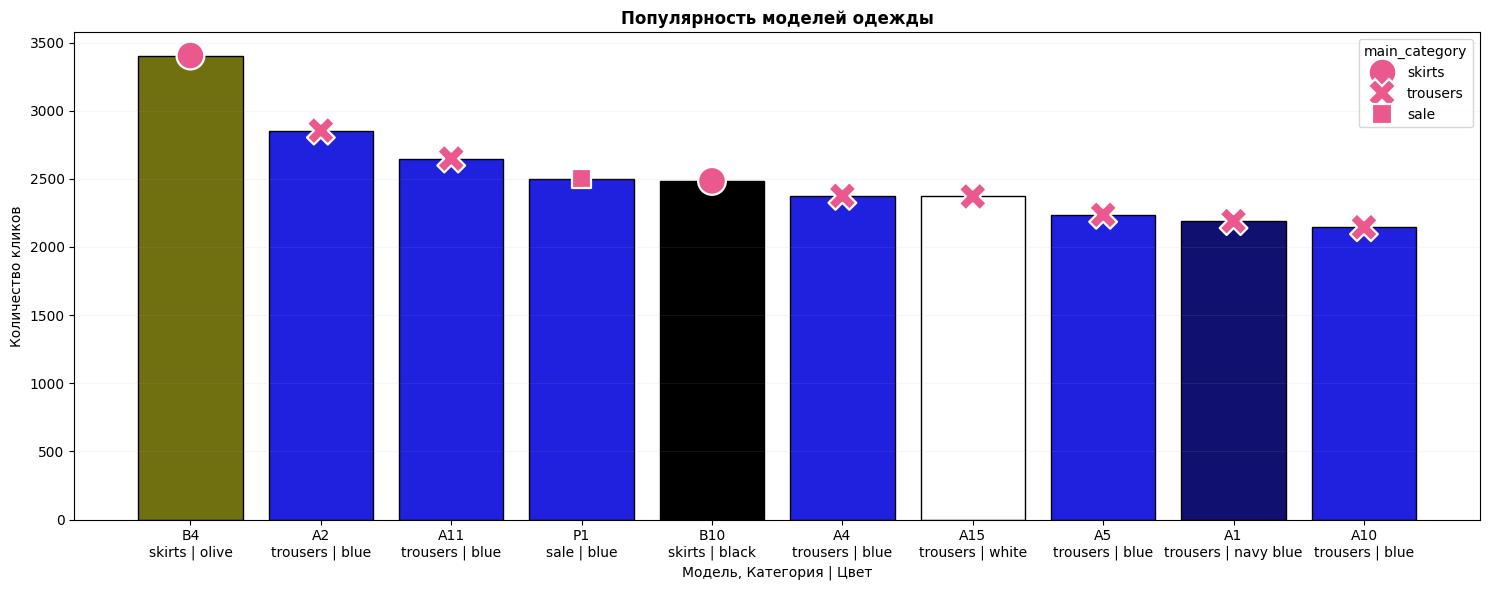

In [60]:
plt.figure(figsize=(15, 6))

sns.barplot(data=models_count, x="labels", y="count", hue="colour", palette=color_palette, legend=False, edgecolor="black",
    linewidth=1)
sns.scatterplot(data=models_count, x="labels", y="count", style="main_category", s=400, color="#EA588D")
plt.title("Популярность моделей одежды", fontweight="bold")
plt.xlabel("Модель, Категория | Цвет")
plt.ylabel("Количество кликов")
plt.grid(axis='y', alpha=0.1)
plt.tight_layout()
plt.show()


Самая популярная модель - B4, оливковая юбка. Так же в топ-10 популрных моделей входят 7 синих штанов, вероятно, джинсы

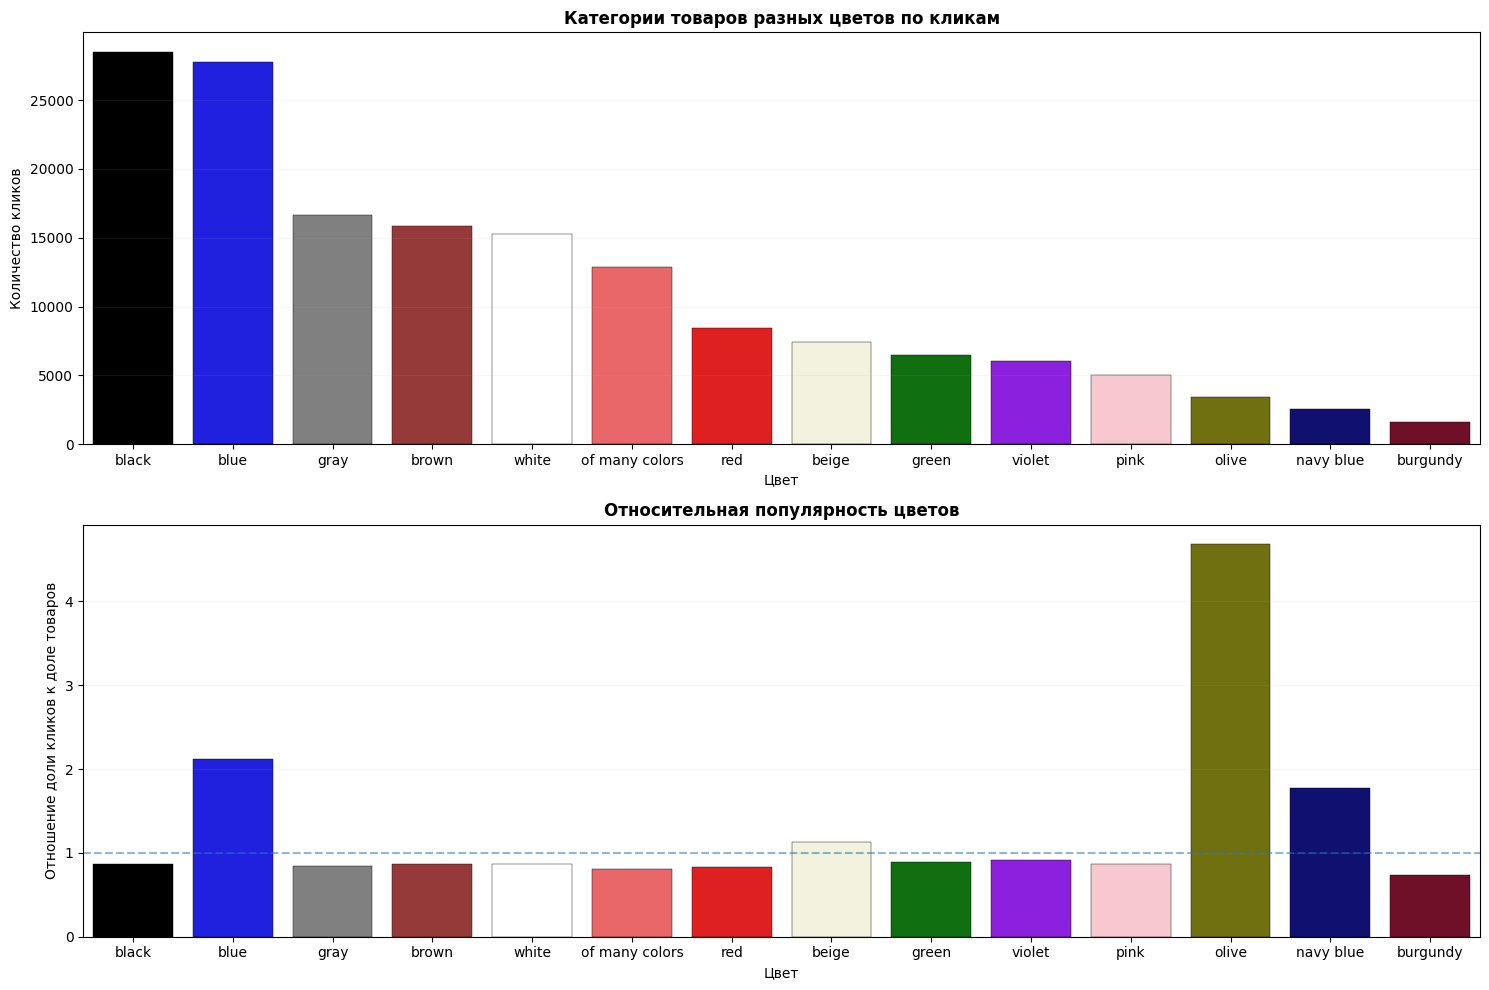

In [61]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.countplot(data=df, x='colour', hue='colour', palette=color_palette, edgecolor="black", linewidth=0.3, order=df["colour"].value_counts().index)
plt.title('Категории товаров разных цветов по кликам', fontweight='bold')
plt.ylabel('Количество кликов')
plt.xlabel('Цвет')
plt.grid(axis='y', alpha=0.1)

clicks_share2 = df['colour'].value_counts(normalize=True).reset_index()
catalog_share2 = df_aggregated['colour'].value_counts(normalize=True).reset_index()
shares2 = pd.merge(clicks_share2, catalog_share2, on="colour")
shares2['relative_interest'] = shares2['proportion_x'] / shares2['proportion_y']

plt.subplot(2, 1, 2)
sns.barplot(data=shares2, x='colour', y='relative_interest', hue='colour', palette=color_palette, edgecolor="black", linewidth=0.3)

plt.axhline(1, linestyle='--', alpha=0.5)
plt.title('Относительная популярность цветов', fontweight='bold')
plt.ylabel('Отношение доли кликов к доле товаров')
plt.xlabel('Цвет')
plt.grid(axis='y', alpha=0.1)

plt.tight_layout()
plt.show()

Есть повышенный спрос на синие, темно-синие, оливrjdst и немного на бежевые вещи.

#### location и model_pose

In [62]:
location_palette = {
    "top left": sns.color_palette("magma")[0],
    "top in the middle": sns.color_palette("magma")[1],
    "bottom in the middle": sns.color_palette("magma")[2],
    "bottom left": sns.color_palette("magma")[3],
    "top right": sns.color_palette("magma")[4],
    "bottom right": sns.color_palette("magma")[5]
}

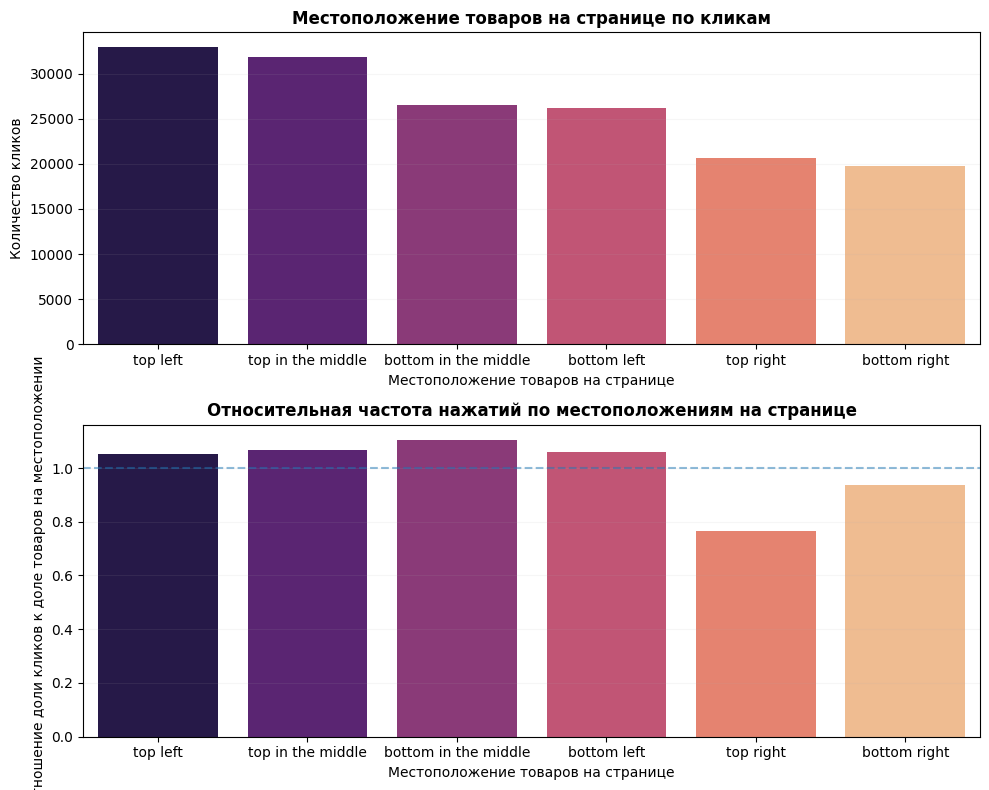

In [63]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
sns.countplot(data=df, x='location', hue='location', palette=location_palette, order=df["location"].value_counts().index)
plt.title('Местоположение товаров на странице по кликам', fontweight='bold')
plt.ylabel('Количество кликов')
plt.xlabel('Местоположение товаров на странице')
plt.grid(axis='y', alpha=0.1)

clicks_share3 = df['location'].value_counts(normalize=True).reset_index()
catalog_share3 = df_aggregated['location'].value_counts(normalize=True).reset_index()
shares3 = pd.merge(clicks_share3, catalog_share3, on="location")
shares3['relative_interest'] = shares3['proportion_x'] / shares3['proportion_y']

plt.subplot(2, 1, 2)
sns.barplot(data=shares3, x='location', y='relative_interest', hue='location', palette=location_palette)

plt.axhline(1, linestyle='--', alpha=0.5)
plt.title('Относительная частота нажатий по местоположениям на странице', fontweight='bold')
plt.ylabel('Отношение доли кликов к доле товаров на местоположении')
plt.xlabel('Местоположение товаров на странице')
plt.grid(axis='y', alpha=0.1)

plt.tight_layout()
plt.show()

В правый верхний угол тыкают значительно реже, возможно там менее популярные позиции или менее удобная зона для нажатия.

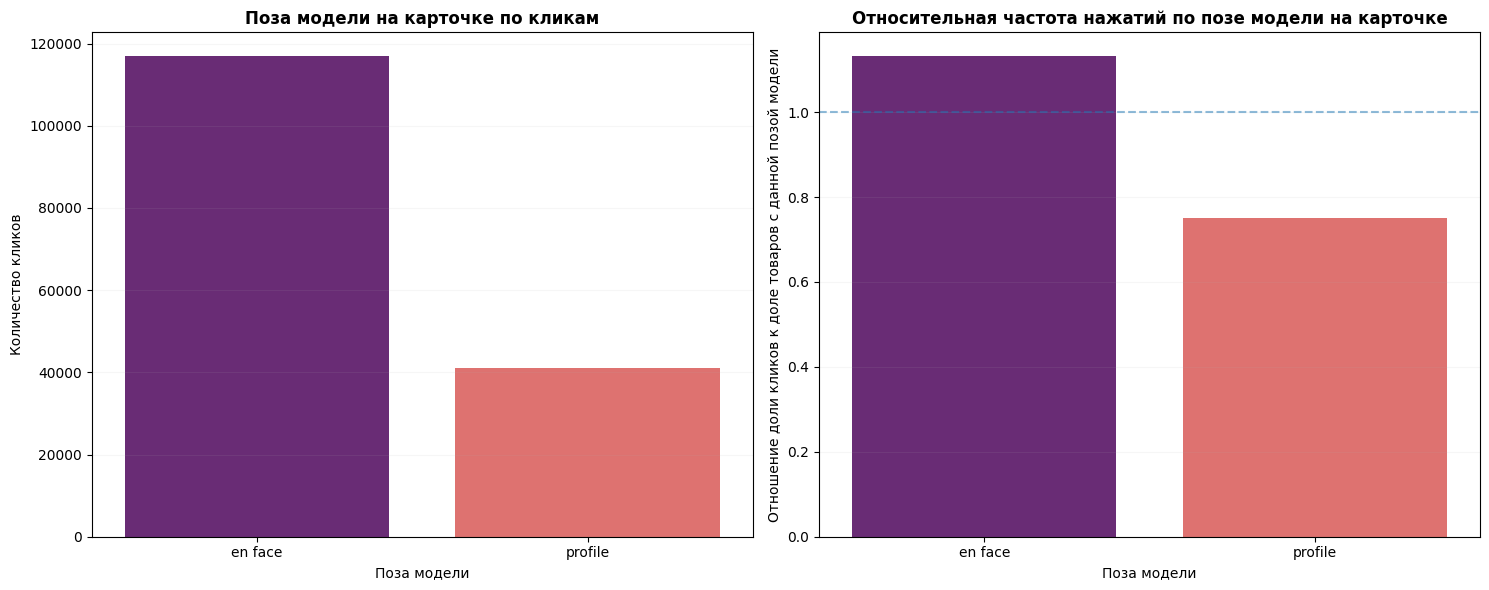

In [64]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='model_pose', hue='model_pose', palette="magma")
plt.title('Поза модели на карточке по кликам', fontweight='bold')
plt.ylabel('Количество кликов')
plt.xlabel('Поза модели')
plt.grid(axis='y', alpha=0.1)

clicks_share4 = df['model_pose'].value_counts(normalize=True).reset_index()
catalog_share4 = df_aggregated['model_pose'].value_counts(normalize=True).reset_index()
shares4 = pd.merge(clicks_share4, catalog_share4, on="model_pose")
shares4['relative_interest'] = shares4['proportion_x'] / shares4['proportion_y']

plt.subplot(1, 2, 2)
sns.barplot(data=shares4, x='model_pose', y='relative_interest', hue='model_pose', palette="magma")

plt.axhline(1, linestyle='--', alpha=0.5)
plt.title('Относительная частота нажатий по позе модели на карточке', fontweight='bold')
plt.ylabel('Отношение доли кликов к доле товаров с данной позой модели')
plt.xlabel('Поза модели')
plt.grid(axis='y', alpha=0.1)

plt.tight_layout()
plt.show()

#### Цена

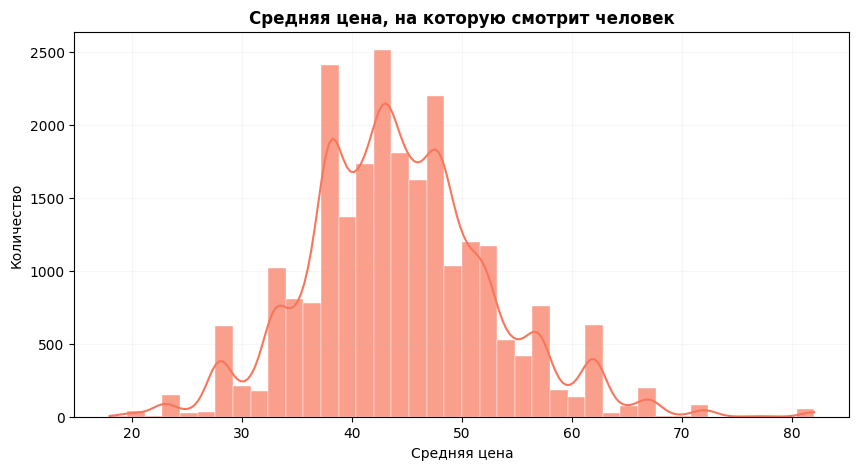

In [65]:
avg_price_per_session = df.groupby('session_id')['price'].mean()

plt.figure(figsize=(10, 5))
sns.histplot(avg_price_per_session, bins=40, alpha=0.7, edgecolor="white", linewidth=0.3, color=sns.color_palette("magma")[4], kde=True)
plt.title('Средняя цена, на которую смотрит человек', fontweight='bold')
plt.ylabel('Количество')
plt.xlabel('Средняя цена')
plt.grid(alpha=0.1)

plt.show()

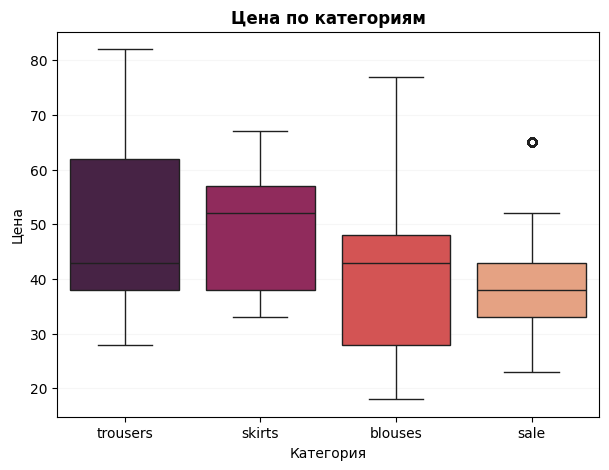

In [66]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='main_category', hue='main_category', y='price', palette='rocket')
plt.title('Цена по категориям', fontweight='bold')
plt.xlabel('Категория')
plt.ylabel('Цена')
plt.grid(axis='y', alpha=0.1)

plt.show()

#### page

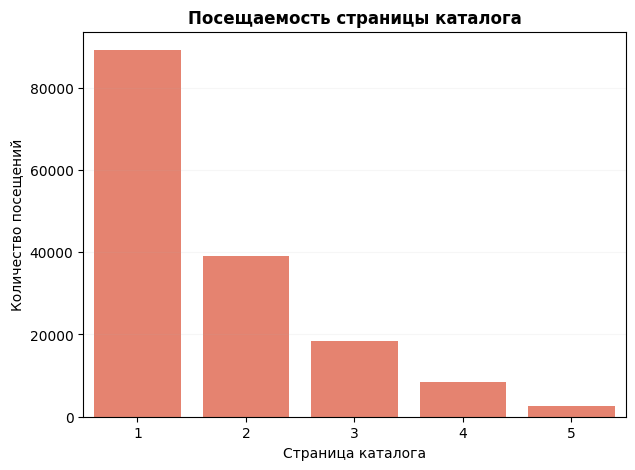

In [67]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="page", color=sns.color_palette("magma")[4])
plt.title("Посещаемость страницы каталога", fontweight="bold")
plt.xlabel("Страница каталога")
plt.ylabel("Количество посещений")
plt.grid(axis='y', alpha=0.1)
plt.show()

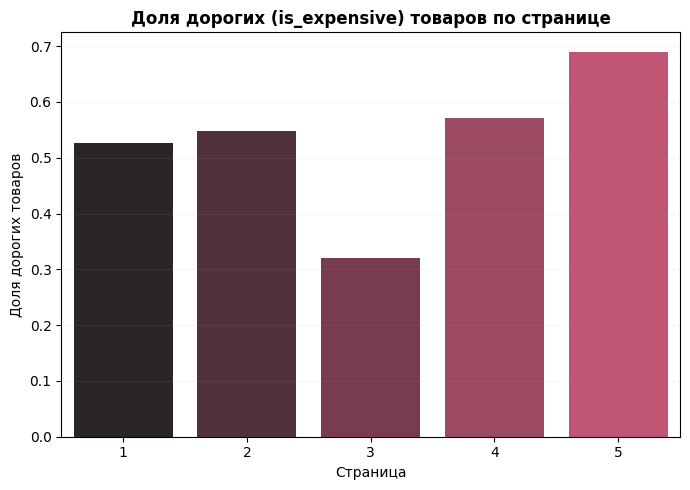

In [68]:
page_price = df.groupby('page')['is_expensive'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=page_price, x='page', y='is_expensive', hue='page', palette='dark:#d3436e', legend=False)

plt.title('Доля дорогих (is_expensive) товаров по странице', fontweight='bold')
plt.ylabel('Доля дорогих товаров')
plt.xlabel('Страница')
plt.grid(axis='y', alpha=0.1)
plt.tight_layout()
plt.show()

#### Страны

In [69]:
countries_price = df.groupby(['session_id', 'country'])['price'].mean().sort_values().reset_index()
countries_price['region'] = countries_price['country'].map({'Poland': 'Poland'}).fillna('Other')

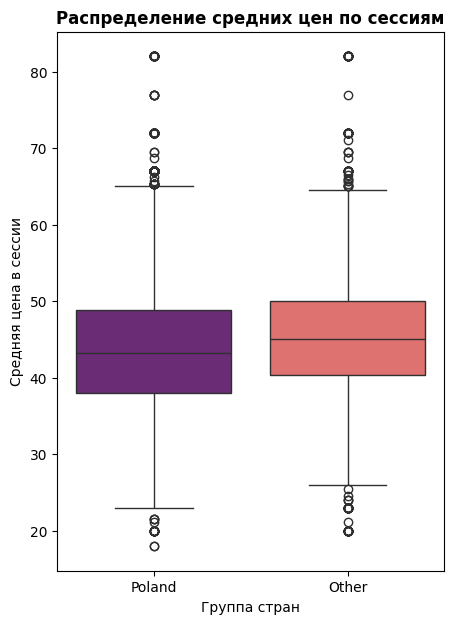

In [70]:
plt.figure(figsize=(5, 7))

sns.boxplot(data=countries_price, x='region', hue='region', y='price', palette='magma')

plt.title('Распределение средних цен по сессиям', fontweight="bold")
plt.xlabel('Группа стран')
plt.ylabel('Средняя цена в сессии')
plt.show()

В Польше люди смотрят на более дешевые товары, чем заграницей

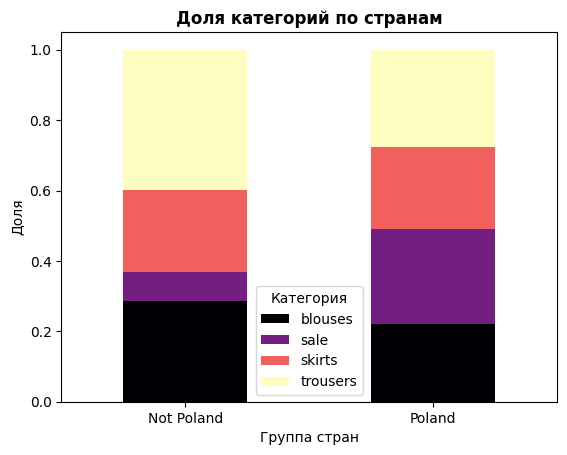

In [71]:
df['country_group'] = df['country'].apply(lambda x: 'Poland' if x == 'Poland' else 'Not Poland')
ct = pd.crosstab(df['country_group'], df['main_category'], normalize='index')

ax = ct.plot(kind='bar', stacked=True, colormap='magma')
plt.title('Доля категорий по странам', fontweight="bold")
plt.xlabel('Группа стран')
plt.ylabel('Доля')
plt.legend(title='Категория')
plt.xticks(rotation=0)
plt.show()

Доли категорий в Польше и заграницей отличаются. Например, вне Польши доля товаров "по акции" меньше, а доля блузок и штанов больше

#### Сессии

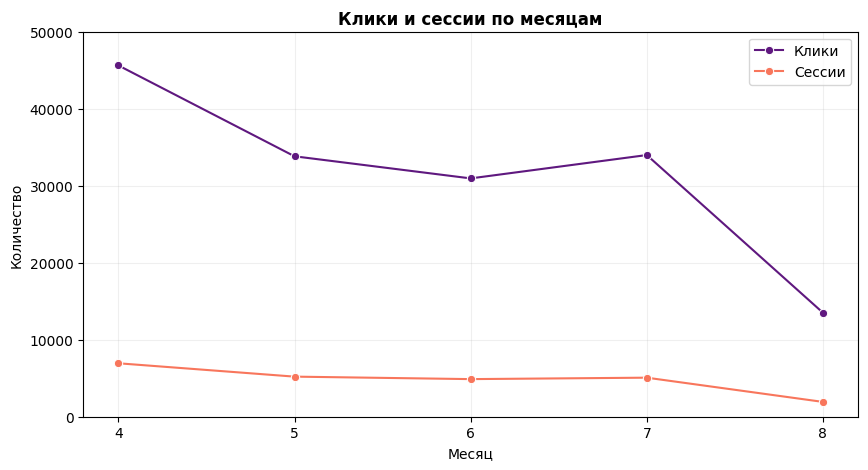

In [72]:
monthly_clicks = df.groupby('month').size().reset_index(name='count')
monthly_session = df.groupby('month').agg({'session_id':"nunique"}).reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_clicks, x='month', y='count', marker='o', color=sns.color_palette("magma")[1], label="Клики")
sns.lineplot(data=monthly_session, x='month', y='session_id', marker='o', color=sns.color_palette("magma")[4], label="Сессии")
plt.title('Клики и сессии по месяцам', fontweight="bold")
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.ylim(0, 50000)
plt.xticks(range(4, 9))
plt.grid(alpha=0.2)
plt.show()

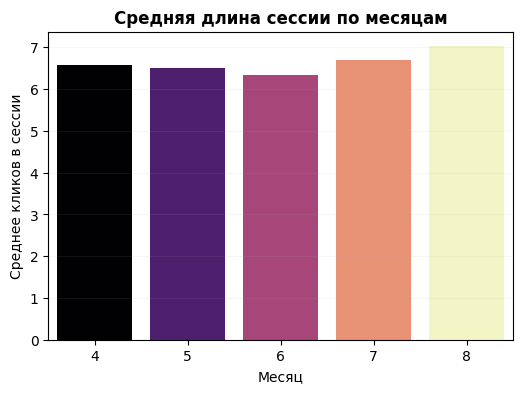

In [73]:
length_by_month = df.groupby(['month', 'session_id']).size().groupby('month').mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=length_by_month, x='month', y=0, hue='month', palette='magma', legend=False)

plt.title('Средняя длина сессии по месяцам', fontweight="bold")
plt.xlabel('Месяц')
plt.ylabel('Среднее кликов в сессии')
plt.grid(axis='y', alpha=0.1)
plt.show()

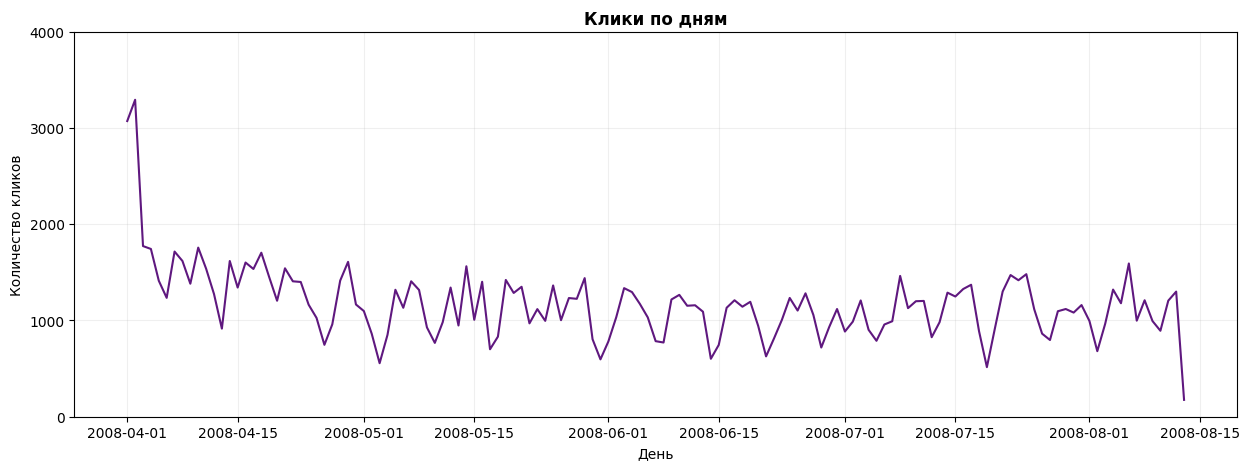

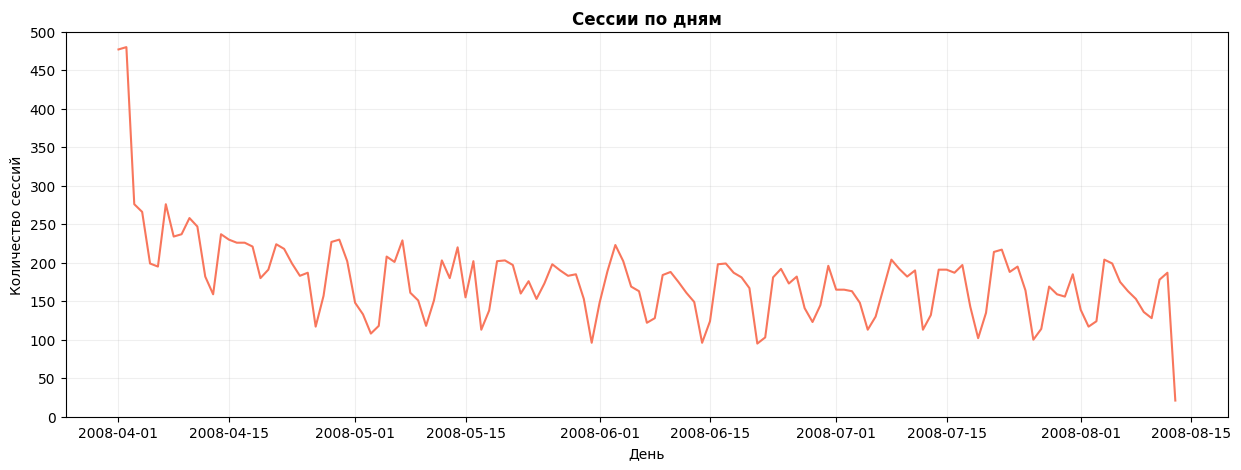

In [74]:
daily_clicks = df.groupby('date').size().reset_index(name='count')

plt.figure(figsize=(15, 5))

sns.lineplot(data=daily_clicks, x='date', y='count',color=sns.color_palette("magma")[1])

plt.title('Клики по дням', fontweight='bold')
plt.xlabel('День')
plt.ylabel('Количество кликов')
plt.ylim(0, 500)
plt.yticks(range(0, 4500, 1000))
plt.grid(alpha=0.2)
plt.show()


daily_session = (df.groupby('date').agg({'session_id': 'nunique'}).reset_index())
plt.figure(figsize=(15, 5))
sns.lineplot(data=daily_session, x='date', y='session_id', color=sns.color_palette("magma")[4])

plt.title('Сессии по дням', fontweight='bold')
plt.xlabel('День')
plt.ylabel('Количество сессий')
plt.yticks(range(0, 501, 50))
plt.ylim(0, 500)
plt.grid(alpha=0.2)
plt.show()


In [75]:
df['day_of_week'] = df['date'].dt.day_name()

In [76]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sessions_by_day = df.groupby('day_of_week')['session_id'].nunique().reindex(day_order).reset_index()
length_by_day = df.groupby(['day_of_week', 'session_id']).size().groupby('day_of_week').mean().reindex(day_order).reset_index()

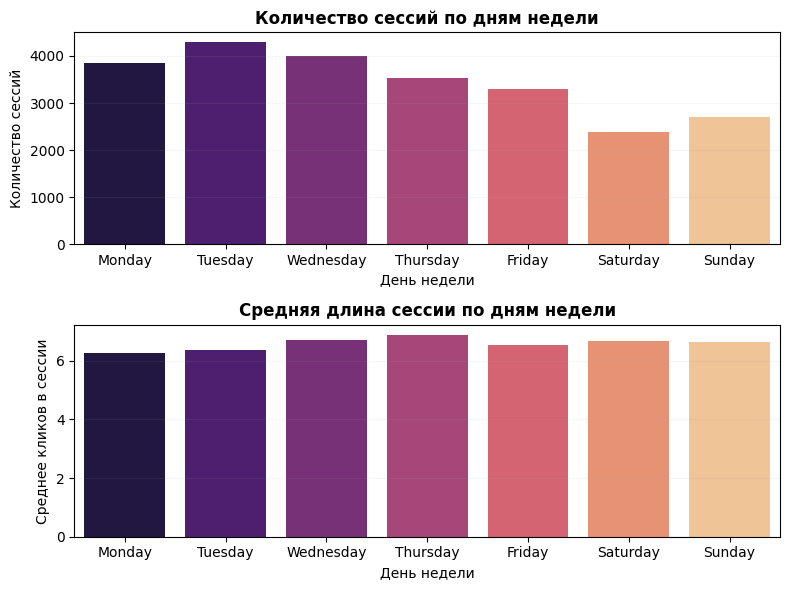

In [77]:
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
sns.barplot(data=sessions_by_day, x='day_of_week', y='session_id', hue='day_of_week',palette='magma')
plt.title('Количество сессий по дням недели', fontweight="bold")
plt.xlabel('День недели')
plt.ylabel('Количество сессий')
plt.grid(axis='y', alpha=0.1)

plt.subplot(2, 1, 2)
sns.barplot(data=length_by_day, x='day_of_week', y=0, hue='day_of_week', palette='magma')
plt.title('Средняя длина сессии по дням недели', fontweight="bold")
plt.xlabel('День недели')
plt.ylabel('Среднее кликов в сессии')
plt.grid(axis='y', alpha=0.1)

plt.tight_layout()
plt.show()

In [78]:
daily_sessions = df.groupby(['day_of_week', df['date'].dt.date])['session_id'].nunique().reset_index()
daily_sessions.columns = ['day_of_week', 'date', 'session_count']
weekend_mask = daily_sessions['day_of_week'].isin(['Saturday', 'Sunday'])
weekend = daily_sessions[weekend_mask]['session_count']
weekday = daily_sessions[~weekend_mask]['session_count']
daily_sessions

,day_of_week,date,session_count
0,Friday,2008-04-04,266
1,Friday,2008-04-11,247
2,Friday,2008-04-18,221
3,Friday,2008-04-25,187
4,Friday,2008-05-02,133
...,...,...,...
130,Wednesday,2008-07-16,187
131,Wednesday,2008-07-23,188
132,Wednesday,2008-07-30,156
133,Wednesday,2008-08-06,175


$H_0$: распределение количества сессий не отличается от нормального <br>

$H_1$: распределение количества сессий в выходные дни отличается от нормального

Уровень значимости = 0.05

In [79]:
stat, p = shapiro(daily_sessions['session_count'])
print(p)

3.438482037909485e-11


p-value < 0.025 -> отвергаем нулевую гипотезу -> количество сессий не распределено нормально

$H_0$: распределение количества сессий в выходные дни не отличается от распределения в будни

$H_1$: количество сессий в выходные дни меньше количества сессий в будни

Уровень значимости = 0.05

In [80]:
stat, p_value = mannwhitneyu(weekend, weekday, alternative="less")
p_value

np.float64(1.459132586708785e-13)

p-value < 0.05 -> отвергаем нулевую гипотезу -> активность в выходные статистически значимо ниже, чем в будни

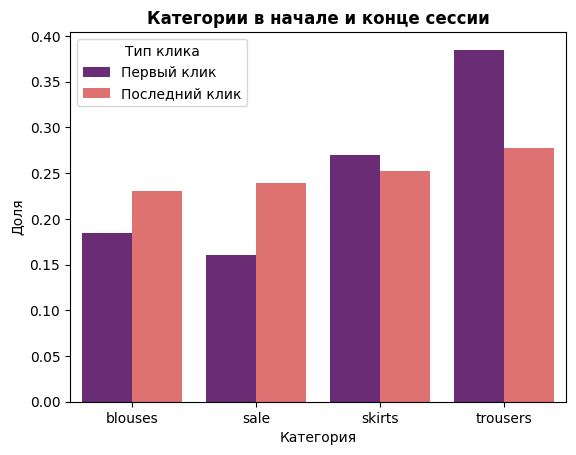

In [81]:
first = df[df['click_order'] == 1]['main_category'].value_counts(normalize=True)
last = df.loc[df.groupby('session_id')['click_order'].idxmax()]['main_category'].value_counts(normalize=True)
fist_last_click = pd.DataFrame({'Первый клик': first, 'Последний клик': last}).reset_index()
fist_last_click = fist_last_click.melt(id_vars='main_category', var_name='Тип клика', value_name='Доля')
sns.barplot(data=fist_last_click, x="main_category", y="Доля", hue='Тип клика', palette='magma')
plt.title('Категории в начале и конце сессии', fontweight="bold")
plt.xlabel("Категория")
plt.show()

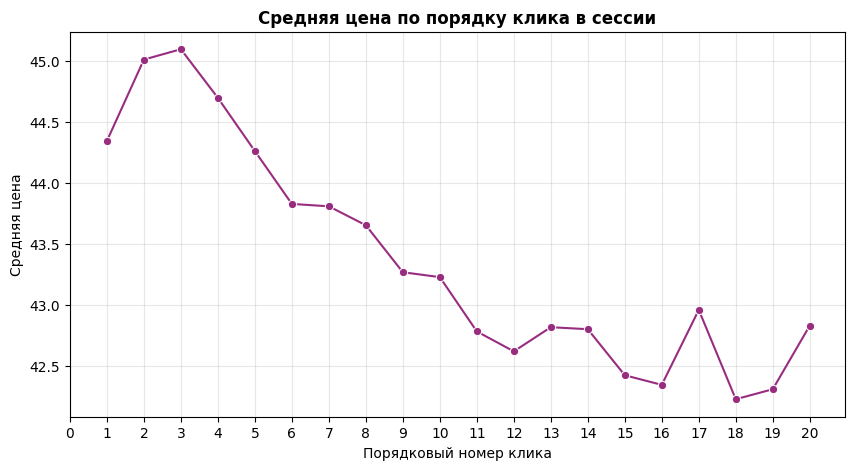

In [82]:
price_by_click = df[df['click_order'] <= 20].groupby('click_order')['price'].mean().reset_index()

plt.figure(figsize=(10, 5))

sns.lineplot(data=price_by_click, x='click_order', y='price', marker='o', color=sns.color_palette("magma")[2])

plt.title('Средняя цена по порядку клика в сессии', fontweight="bold")
plt.xlabel('Порядковый номер клика')
plt.ylabel('Средняя цена')
plt.grid(alpha=0.3)
plt.xticks(range(0, 21))
plt.show()

Рассмотрим зависимости между порядком просмотров товаров из каталога. Например, может быть, если человек начинал свою сессию с просмотра бежевой блузки, то он продолжит просматривать бежевые блузки

In [83]:
df['colorAndType'] = df['colour'] + ' ' + df['main_category']

In [84]:
df_sorted = df.sort_values(['session_id', 'click_order'])

transitions = []

for session_id, group in df_sorted.groupby('session_id'):
    categories = group['colorAndType'].tolist()

    if len(categories) < 2:
        continue
    for i in range(len(categories) - 1):
        transitions.append([categories[i], categories[i + 1]])

transitions_df = pd.DataFrame(transitions, columns=['previous_item', 'next_item'])
transitions_df

,previous_item,next_item
0,beige trousers,beige trousers
1,beige trousers,olive skirts
2,olive skirts,gray skirts
3,gray skirts,brown skirts
4,brown skirts,gray blouses
...,...,...
133857,beige trousers,brown sale
133858,brown sale,black sale
133859,black sale,brown sale
133860,blue trousers,red blouses


In [85]:
top_counts = transitions_df.value_counts(['previous_item', 'next_item']).reset_index(name='count')
top_counts['total'] = top_counts.groupby('previous_item')['count'].transform('sum') # Эта строчка считает общее количество переходов из каждой предыдущей категории.
top_counts['probability'] = (top_counts['count'] / top_counts['total'])
top_counts = top_counts.sort_values('count', ascending=False)

In [86]:
color_palette = {
    "beige": "#F5F5DC",
    "black": "#000000",
    "blue": "#0000FF",
    "brown": "#A52A2A",
    "burgundy": "#800020",
    "gray": "#808080",
    "green": "#008000",
    "navy blue": "#000080",
    "of many colors": "#ff5054",
    "olive": "#808000",
    "pink": "#FFC0CB",
    "red": "#FF0000",
    "violet": "#8F00FF",
    "white": "#FFFFFF"
}

def color_by_name(val):
    val = str(val).lower()
    parts = val.split()
    color_name = " ".join(parts[:-1])
    hex_color = color_palette.get(color_name)

    text_color = "black" if color_name in ["white", "beige"] else "white"

    return f"background-color: {hex_color}; color: {text_color};"

top10 = top_counts.head(10)

beautiful = top10.style.applymap(
    color_by_name,
    subset=['previous_item', 'next_item']
)

beautiful


/tmp/ipykernel_131350/502616160.py:30: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  beautiful = top10.style.applymap(


,previous_item,next_item,count,total,probability
0,blue trousers,blue trousers,10383,19034,0.545498
1,black skirts,black skirts,2327,7972,0.291897
2,blue trousers,black trousers,1949,19034,0.102396
3,black sale,brown sale,1742,7072,0.246324
4,brown sale,brown sale,1700,6923,0.245558
5,brown sale,black sale,1646,6923,0.237758
6,white blouses,white blouses,1485,6855,0.216630
7,black sale,black sale,1467,7072,0.207438
8,navy blue trousers,blue trousers,1375,1955,0.703325
9,blue trousers,beige trousers,1205,19034,0.063308


Чаще всего люди переходят из карточки товара той же категории и цвета на карточку товара той же категории и того же цвета. Так же иногда переходят на товар той же категории другого цвета

#### Взаимосвязи

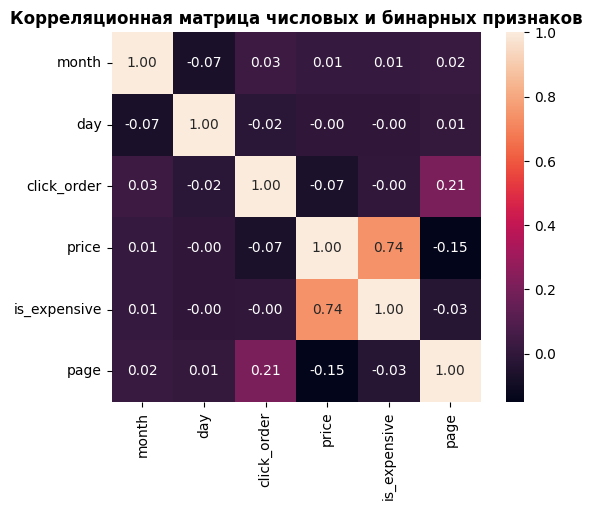

In [87]:
corr = df[['month', 'day', 'click_order', 'price', 'is_expensive', 'page']].corr()
sns.heatmap(corr, annot=True, square=True, fmt=".2f")
plt.title('Корреляционная матрица числовых и бинарных признаков', fontweight="bold")
plt.show()

## Гипотезы

### Гипотеза 1

In [88]:
df['region'] = df['country'].map({'Poland': 'Poland'}).fillna('Other')

**Активные пользователи - пользователи, которые сделали больше 3-х кликов за сессию**

Собираем таблицу, из которой мы можем узнать, сколько было серий подряд кликов на одну категорию в рамках одной сессии

In [89]:
chains = []
for session_id, group in df.sort_values('click_order').groupby('session_id'):
    max_chain = 1
    current_chain = 1
    categories = group['main_category'].tolist()

    for i in range(1, len(categories)):
        if categories[i] == categories[i - 1]:
            current_chain += 1
        else:
            max_chain = max(max_chain, current_chain)
            current_chain = 1

    max_chain = max(max_chain, current_chain)
    chains.append([session_id, max_chain])

chains = pd.DataFrame(chains, columns=['session_id', 'max_num_of_chain'])

In [90]:
clicks = df.groupby('session_id')['click_order'].max().reset_index()
clicks = clicks[clicks['click_order'] >= 3]

In [91]:
clicks_x_chains = pd.merge(chains, clicks, on='session_id')

In [92]:
clicks_x_chains

,session_id,max_num_of_chain,click_order
0,1,3,9
1,2,4,9
2,3,4,6
3,4,2,4
4,6,3,5
...,...,...,...
15317,24020,3,5
15318,24021,2,5
15319,24022,3,3
15320,24023,4,7


Собираем группы:
пользователи, у которых не менее 3 кликов подряд на одинаковую категорию, при этом общее количество кликов не менее 3 - группа А, <br>
пользователи, у которых менее 3 кликов подряд на одинаковую категорию, при этом общее количество кликов не менее 3  - группа Б

Хотим проверить, различается ли значение общего количества кликов между группой А и Б. Формулировку гипотез см. ниже


In [93]:
groupA = clicks_x_chains[(clicks_x_chains['max_num_of_chain'] >= 3)]['click_order']
groupB = clicks_x_chains[(clicks_x_chains['max_num_of_chain'] < 3)]['click_order']

In [94]:
groupA.median(), groupB.median(), groupA.mean(), groupB.mean()

(8.0, 3.0, np.float64(10.661932041120615), np.float64(3.905001938735944))

Сначала нужно проверить нормальность распределения количества кликов, для этого мы хотели использовать тест Шапиро Уилка.

Но размер выборки слишком большой для использования этого теста, поэтому посмотрим на qq-плот

In [95]:
groupA.shape, groupB.shape

((12743,), (2579,))

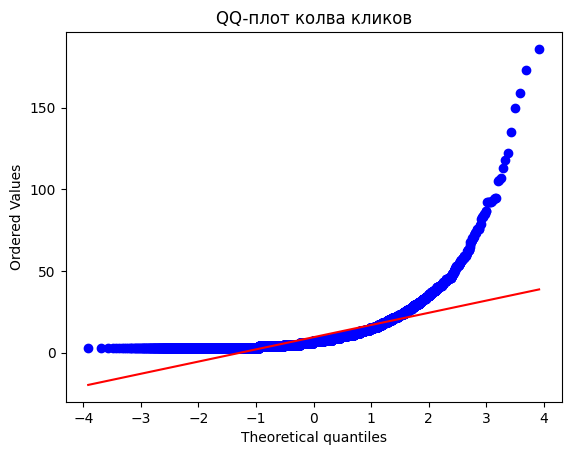

In [96]:
stats.probplot(clicks_x_chains['click_order'], dist="norm", plot=plt)
plt.title("QQ-плот колва кликов")
plt.show()


Данные не распределены нормально, поэтому используем тест Манна Уитни

Поэтому проводим непараметрический тест манна уитни:

$H_0$ - Количество кликов в группе А меньше или равно количеству кликов в группе Б   
$H_1$  - Количество кликов в группе А больше количества кликов в группе Б

In [97]:
stat, p_value = mannwhitneyu(groupA, groupB, alternative='greater')

stat, p_value

(np.float64(28176074.5), np.float64(0.0))

Так как выборки большие - хотим показать, что p_value = 0 не ошибка и тест рабочий, возьмем небольшие рандомные семплы из выборок чтобы это показать

In [98]:
stat, p_value = mannwhitneyu(
    groupA.sample(15, random_state=42),
    groupB.sample(5, random_state=42),
    alternative='greater'
)

stat, p_value

(np.float64(68.0), np.float64(0.004126322719489763))

Так как получили p_value < 0.05 отклоняем $H_0$ в пользу $H_1$ - кол-во кликов в группе А действительно больше чем в группе Б

### Гипотеза 2

$H_0$ - Следующая просматриваемая категория **не** зависит от предыдущей категории просмотра.

$H_1$ - Следующая просматриваемая категория зависит от предыдущей категории просмотра.


In [99]:
df_sorted = df.sort_values(['session_id', 'click_order'])

transitions = []

for session_id, group in df_sorted.groupby('session_id'):
    categories = group['colorAndType'].tolist()

    if len(categories) < 3:
        continue
    for i in range(len(categories) - 1):
        transitions.append([categories[i], categories[i + 1]])

transitions_df = pd.DataFrame(transitions, columns=['previous_item', 'next_item'])
contingency_table = pd.crosstab(transitions_df['previous_item'], transitions_df['next_item'])
contingency_table

next_item,beige sale,beige skirts,beige trousers,black blouses,black sale,black skirts,black trousers,blue blouses,blue sale,blue skirts,...,red blouses,red sale,red skirts,red trousers,violet blouses,violet skirts,white blouses,white sale,white skirts,white trousers
previous_item,,,,,,,,,,,,,,,,,,,,,
beige sale,0,3,6,1,34,5,3,0,0,0,...,1,50,1,0,3,0,5,79,0,0
beige skirts,0,0,5,4,11,203,9,0,6,25,...,4,0,69,0,4,21,31,4,11,7
beige trousers,3,16,942,26,48,51,796,1,49,20,...,28,0,47,43,27,9,63,7,5,357
black blouses,1,4,26,313,64,43,28,13,38,5,...,173,1,13,0,259,4,619,11,0,8
black sale,45,2,33,39,1454,90,59,1,416,15,...,29,52,27,4,25,5,62,640,2,18
black skirts,0,117,56,67,88,2258,69,2,66,87,...,46,4,1147,3,58,354,143,21,46,34
black trousers,0,12,681,57,121,162,1154,2,82,45,...,52,1,65,86,67,16,102,18,9,208
blue blouses,0,0,5,26,1,1,1,0,0,0,...,26,0,2,0,14,0,73,0,0,1
blue sale,14,4,20,11,1025,25,25,0,638,7,...,13,11,21,0,18,0,36,81,3,24



Мы используем тест хи квадрат, потому что здесь мы проверяем: зависит ли одна категориальная переменная от другой. хи квадрат проверят, отличаются ли наблюдаемые частоты от случайных (случайного распределениия).


In [100]:
chi2, p_value, d, e = chi2_contingency(contingency_table)

print(f"Хи квадрат статистика: {chi2:.2f}")
print(f"p-value: {p_value:.3e}")

Хи квадрат статистика: 303072.19
p-value: 0.000e+00



Значение статистики хи квадрат указывает на сильное отличие наблюдаемых переходов между категориями от случайного распределения. Это свидетельствует о наличии статистически значимой зависимости между предыдущей и следующей просматриваемыми категориями товаров.

p-value = 0 из-за очень большого объема данных и сильной чувствительности теста хи квардрат

По итогу стат теста мы отклоняем $H_0$ в пользу $H_1$

In [101]:
top_counts = transitions_df.value_counts(['previous_item', 'next_item']).reset_index(name='count')
top_counts['total'] = top_counts.groupby('previous_item')['count'].transform('sum') # Эта строчка считает общее количество переходов из каждой предыдущей категории.
top_counts['probability'] = (top_counts['count'] / top_counts['total'])
top_counts = top_counts.sort_values('count', ascending=False)

top_counts.head(10)

,previous_item,next_item,count,total,probability
0,blue trousers,blue trousers,10149,18439,0.550409
1,black skirts,black skirts,2258,7717,0.292601
2,blue trousers,black trousers,1895,18439,0.102771
3,black sale,brown sale,1722,6961,0.247378
4,brown sale,brown sale,1686,6811,0.247541
5,brown sale,black sale,1626,6811,0.238731
6,white blouses,white blouses,1463,6735,0.217223
7,black sale,black sale,1454,6961,0.208878
8,navy blue trousers,blue trousers,1314,1847,0.711424
9,blue trousers,beige trousers,1173,18439,0.063615


### Гипотеза 3

Хотим проверить гипотезу, правда ли что пользователи из Польши в среднем кликают на менее дорогие товары, чем клиенты из других стран

In [102]:



prices_per_sessions = df.groupby(['session_id', 'region'])['price'].mean().reset_index()
prices_per_sessions

,session_id,region,price
0,1,Poland,42.111111
1,2,Poland,51.333333
2,3,Other,42.166667
3,4,Other,45.250000
4,5,Other,57.000000
...,...,...,...
24021,24022,Poland,29.666667
24022,24023,Poland,35.142857
24023,24024,Poland,67.000000
24024,24025,Other,62.000000


In [103]:
prices_per_sessions.shape

(24026, 3)

И снова выборка слишком велика для Шапиро-Уилка, воспользуемся qq-плотом

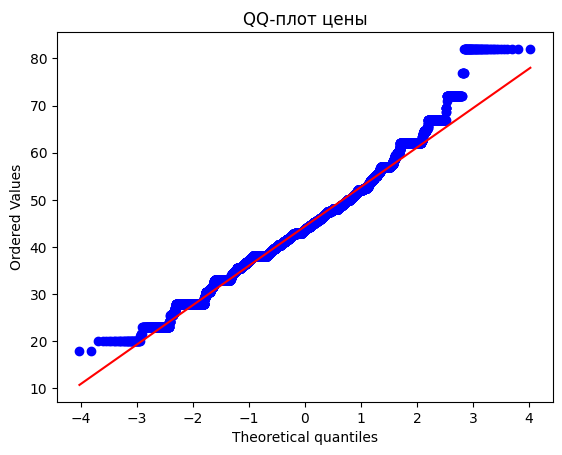

In [104]:
stats.probplot(prices_per_sessions['price'], dist="norm", plot=plt)
plt.title("QQ-плот цены")
plt.show()

Попробуем убрать сессии с меннее чем 3 кликами, то есть оставим только активных пользователей в рамках сессии

In [105]:
prices_per_sessions_filtered = pd.merge(prices_per_sessions, clicks_x_chains, on='session_id')

In [106]:
prices_per_sessions_filtered.shape, prices_per_sessions.shape

((15322, 5), (24026, 3))

In [107]:
other = prices_per_sessions_filtered[prices_per_sessions_filtered['region'] == 'Other']['price']
poland = prices_per_sessions_filtered[prices_per_sessions_filtered['region'] == 'Poland']['price']
other.shape, poland.shape

((2706,), (12616,))

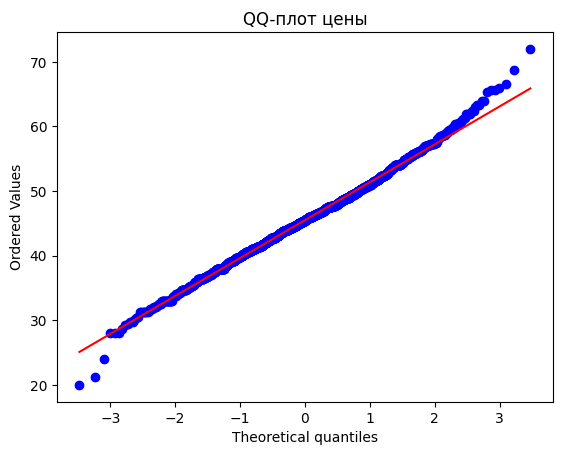

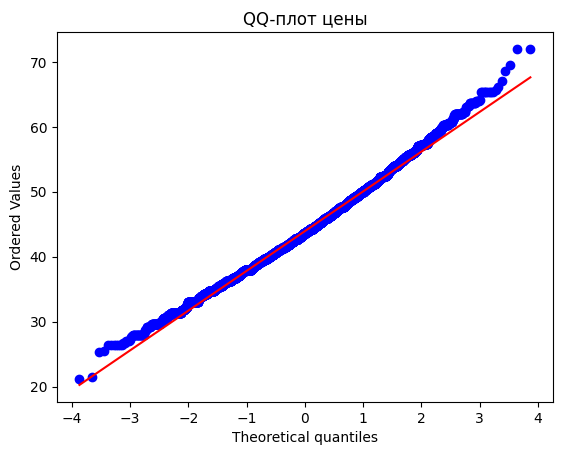

In [108]:
stats.probplot(other, dist="norm", plot=plt)
plt.title("QQ-плот цены")
plt.show()
stats.probplot(poland, dist="norm", plot=plt)
plt.title("QQ-плот цены")
plt.show()

Будем считать, что распределены нормально

$H_0$ - активные пользователи из Польши кликают на товары **той же** стоимости, что и пользователи из других стран     
$H_1$ - активные пользователи из Польши кликают на товары **другой** стоимости, что и пользователи из других стран

Так как мы работает с несвязными выборками (пользователи из разных стран), должны проверить на гомогенность дисперсий. Воспользуемся критерием Левена.

$H_0$ - дисперсии средних цен на товары кликнутых активными пользователями в рамках одной сессии из Польши и других стран гомогенны   

$H_1$ - дисперсии ... **не**гомогенны

In [109]:
levene(poland, other)

LeveneResult(statistic=np.float64(15.213115807190817), pvalue=np.float64(9.644408293399377e-05))

Тк p_value < 0.05 Отклоняем $H_0$ в пользу $H_1$. Дисперсии негомогенны.  

Используем t-тест для проверки изначальной гипотезы

In [110]:

t_stat, p_value = stats.ttest_ind(poland, other, equal_var=False)

print(f'статистика: {t_stat:.4f}')
print(f'p-value: {p_value:.3e}')

статистика: -12.3715
p-value: 1.545e-34


Так как p_value < 0.05 отклоняем нулевую гипотезу в пользу $H_1$.  


Сравним полученные результаты с тестом Манна Уитни

In [111]:
stat, p_value = mannwhitneyu(poland, other, alternative='two-sided')

print(f'статистика: {stat:.4f}')
print(f'p-value: {p_value:.3e}')


статистика: 14361330.0000
p-value: 1.790e-38


/tmp/ipykernel_131350/2259647166.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([poland, other], labels=['Польша', 'Другие страны'])


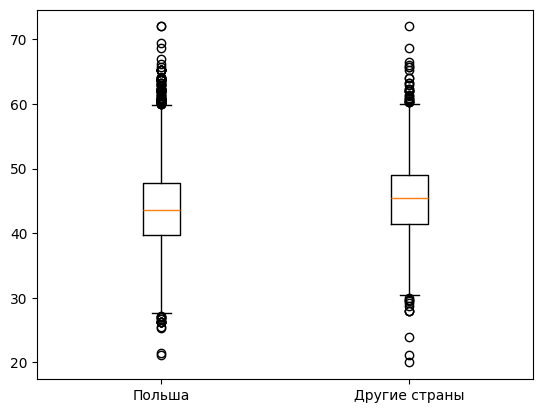

In [112]:
plt.boxplot([poland, other], labels=['Польша', 'Другие страны'])
plt.show()

In [113]:
round(poland.mean()-other.mean(), 3)

np.float64(-1.552)

Разница между средними - 1,5 доллара

## Генератор эмодзи

In [114]:
from random import randint
for i in range(100000):
  random_code = randint(0x1F600, 0x1F64F)
  emoji_char = chr(random_code)
  print(emoji_char, end="")
  if i%50 == 0:
    print()

😱
😼🙄😦😏😯😲🙆😬😀😅😰🙉😮😺😪😡😜😋😣😣🙆😓🙈🙏🙅😻😯😝😵🙃🙉😹😰😤😃😩😒😝😁😕😙🙇😎😈🙂😳😞😷🙄😷
😟😚😤😨🙍😨😑😴😼😲😺😊😖🙈🙃😿🙉😀🙋🙁😘🙅😵😙😂😷🙋😢🙈😔😯😵😩😔😔😩😝😱😴😥😖😆😅😖😿😔😼🙋😗😮
🙋😬😜😃😍😐😹😷😼😑😸😺😒😝😻😩😤😿😁😛😝😙😬😾😂😏😋😣😌😏🙎🙁😍😩😑😯😏😭😮😻😅😝😣😫🙌😂😊🙅😟😣
😒😏😨🙁😓🙇😾😮😅😳😒🙇😾😇🙉😖😱🙆🙇😥😗😅🙃🙍🙉😯🙉😴😷😆😆😭😩😬🙌😱😓🙇😾😆😗😠😊😽😿😹😔😤🙅😌
😯😏😟🙇😃😖😺😀😃😋😀🙄😐😇🙇😏😐😸😘🙏😃🙎😩😖😑😜😒😈😗🙆😟🙋😏🙃😪🙏😑😄😽😾😫😑🙁😀😍😎🙎😎😹😵
😛😌😷😶😎😯🙊😌😷😱😮😮😚😶😴😑🙈🙍🙂😋😴😥😣😟😡😪🙌😪😠😷🙄😭😪😘😁😟😘😘😥😉🙉😒😧🙇😰🙊😰😖🙅😬
😂😥😾😙😩😡😉🙅🙌😣😔😻😁😯😙😁🙋😚😣😉😼😹😆😎😓😌🙁😍😿🙃😬😢😭😁😸😍😉🙋😈🙄🙍😷🙆😫🙈😃🙊😜😳😧
🙅😑😻😄😐😹😠😭😔😯😬😋😻😒😙🙎😀😾😩😯😴😁😎😧😓😅😕🙃😳🙏😂😙😕😀😜🙄😧😺😖😶😹😷😄😙😦😸🙍😯😎🙂
😅😰😎😏😴🙆😄😞😰😰😭😬😍😒😈😱😚🙃😘😜😱🙉🙀🙂😷😒😏😊😓😵😲😡😤😽😪😤😿😬😲🙌😚😒😦😑😨😪😨😠😴😮
🙊😢😊😩🙋😍😳🙀😯😵😽🙆🙌😊😥😱😯😖🙊😻😽🙈😸😳😕🙊😯😄😹😰😖😸😏😧😰😨🙉😇😄🙈😩😓😚😷😿😵😃😱🙄😈
😃😐🙄😯😾😩😪😭😼😛🙏😥🙉😩😞😵🙏😄😎😯😵😢🙋😹🙆😱😊😴🙎😯😙😄😻😮😀😓😴😤😢😛🙈😖😺😃😗😀😈😦😤😻
😂😞😡😽😝😍😶😩😠😏😸🙏😷🙈😬😡😣😸🙁😞😆🙁🙍😹😋😶😇😱😑😚😀😱😣😒😉🙉😾😠🙊😔😶😅😂😝😹😊😥😑🙌😝
🙅😋🙆😙😲😷🙇😅😧😲😀😴😦😥😁😣😇😐😲😃😺🙅😓😛😉😹😒😏🙋😷😣😵😋🙃😛😾😭😬😬😺🙅😛😆😷🙏😋😶😽😇😓
🙁😼😖😇😐😂😚🙄😫😳😁😹😢😞😫😜😞🙃🙄🙆🙀😆🙄😣😲😻😪🙈😆😏😕😰😫🙁🙏😝😙😒😋😯😄😁😕😅😆😈😸😍😏😤
😠😫😊😴😆😒😊😀😽😦😴😷😍😖🙃🙂😦😷🙋😼🙎😓😼😐😎😯🙋😻😭😦😔😱😱😊😥😞🙎😭😾😼😲😚😭😸😮😛🙋😬😻🙏
😏😱😐😍😉🙄😗😵😩😘😭😴😧😹😧😖😀😝🙀😜🙄😲😱😵😒🙄😴😀😎😇😒😔😲😬🙊😤😮🙍😤😗😊😔😤🙀😭😻😗🙁🙋😈
🙊😣😢🙈😖😡🙆😯😛😍😯😈😌😥🙂🙆😳😬😇🙀😄🙉😀😺😟🙆😻🙇😪🙊😺🙈😾😤😪😎😓😐😔😂😌😄😘🙂🙊😲🙌🙋😩😦
😯🙇😺😱😛😠😌😽😊😌😤😤😮😟😂😐😌🙀😚🙏😢🙀😥😉😔😦😭😬😩🙏😨🙋😴😡😫😎🙆😟😓🙀🙊😤😕🙅🙉😨😷😄🙇😥
😒😃😻🙈😁😼😅🙍😙🙄😓😲😃😺🙃🙆😞😡😍😟😋🙄😎😿😇😓😺😞😨😟😪😔😧🙁🙏😑🙁😉😽😢😎😲😇😇😚🙉🙉🙃😣🙉
😪😿😔😷😜😬😊🙍😻🙈😒😘🙉😐😃🙏😼😊😲😷😌😜😫😔😢😡😴😫🙏